In [1]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re

import time
import torch
import torch.nn

import random
import pickle

# import self-defined module
from utils_eval import AverageMeter

In [2]:
if torch.cuda.is_available():
    print(torch.cuda.current_device())
    print(torch.cuda.device(0))
    print(torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA is not available.')

0
1
NVIDIA A100-PCIE-40GB


In [3]:
import torch.backends.cudnn as cudnn
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    # work on a single GPU or CPU
    cudnn.benchmark=True
else:
    device = torch.device("cpu")
    cudnn.benchmark=False

print(device)
print(torch.cuda.get_device_name(0))

cuda:0
NVIDIA A100-PCIE-40GB


In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# 1. Load data

### a. Microbiome

In [5]:
microbiome_df = pd.read_csv('../data/combined.genus_abundance.with_archaea_bacteria_only.clr.transformed.csv', index_col=0)

In [6]:
GENERATE_METADATA = False

In [7]:
if GENERATE_METADATA:
    import requests
    import pandas as pd

    # List of file UUIDs
    file_uuids = microbiome_df.index

    # Initialize an empty list to store data
    metadata_list = []

    # Base URL for the GDC API
    base_url = "https://api.gdc.cancer.gov/files/"
    params = {
        "expand": "cases.samples,annotations",
    }

    # Loop through each file UUID
    for i, file_uuid in enumerate(file_uuids[414:]):
        print(i, file_uuid)
        # Fetch metadata for the file
        url = f"{base_url}{file_uuid}"
        response = requests.get(url, params=params)
        metadata = response.json()
        
        # Extract the required information
        experimental_strategy = metadata['data']['experimental_strategy']
        
        # Iterate over the samples associated with the file
        for case in metadata['data'].get('cases', []):
            for sample in case.get('samples', []):
                submitter_id = sample['submitter_id']
                sample_id = sample['sample_id']
                sample_type = sample['sample_type']
                
                # Append a row to the data list
                metadata_list.append({
                    "file_uuid": file_uuid,
                    "submitter_id": submitter_id,
                    "sample_id": sample_id,
                    "sample_type": sample_type,
                    "experimental_strategy": experimental_strategy
                })

    # Create a pandas DataFrame
    metadata_df = pd.DataFrame(metadata_list)
    metadata_df.to_csv('../data/metadata_df.csv', index=False)
else:
    metadata_df = pd.read_csv('../data/metadata_df.csv')


In [8]:
microbiome_metadata_df = pd.merge(left=microbiome_df, right=metadata_df, how='left', left_index=True, right_on='file_uuid')

# only keep the first row for each TCGA barcode
microbiome_metadata_df['barcode_base'] = microbiome_metadata_df['submitter_id'].str[:-1]
microbiome_metadata_df = microbiome_metadata_df.sort_values('submitter_id', ascending=True).drop_duplicates(subset='barcode_base', keep='first')
microbiome_metadata_df = microbiome_metadata_df.drop(columns=['submitter_id'])

### b. Mutation/CNV and clinical varaibles

In [9]:
### Read molecular signature data
mutation_cnv_df = pd.read_excel('../data/Master Table-Alteration in CNV, Mut, Pathway .xlsx', 
                                 sheet_name='CNV and mutation', header=0, index_col=0)

### Delete the last column
mutation_cnv_df = mutation_cnv_df.drop(columns=[mutation_cnv_df.columns[-1]])

### Read clinical varaible data
clinical_immune_variables_df = pd.read_excel('../data/Master Table-Alteration in CNV, Mut, Pathway .xlsx', sheet_name='Clinical variables', 
                                     header=0, index_col=1, na_values=['[Not Applicable]', '#N/A', '[Not Available]', 
                                                                     '[Discrepancy]', '[Not Evaluated]', '[Unknown]'])

# Remove duplicate columns
import re
for c in clinical_immune_variables_df.columns:
    if re.search('.*[.]\d', c):
        clinical_immune_variables_df = clinical_immune_variables_df.drop(columns = [c])
clinical_immune_variables_df = clinical_immune_variables_df.drop(columns = ['OS Time', 'OS.time (months)', 'OS', 
                                                              'PFI Time', 'DSS.time (days)'])

# 2. Process and merge data

In [10]:
def remove_missing_rows(dataset, microbiome_column_index):
    start_idx = microbiome_column_index[0]
    end_idx = microbiome_column_index[1]
    
    na_idx = np.where(pd.isna(dataset.iloc[:,start_idx:end_idx]).sum(axis=1)==(end_idx-start_idx))[0]
    dataset_nona = dataset.drop(dataset.index[na_idx], axis=0)
    return dataset_nona

In [11]:
def subsetting(dataset, columns, remain_value_list):
    for column, remain_value in zip(columns, remain_value_list):
        idx_remain = np.isin(dataset.loc[:, column], remain_value)
        dataset = dataset.loc[idx_remain, :]
    return dataset

In [12]:
def merge_mutation_microbiome(disease, clinical_immune_variables_df, mutation_cnv_df, microbiome_metadata_df, 
                              subsetting_columns=['sample_type', 'experimental_strategy'], 
                              remain_value_list=[['Primary Tumor'], ['RNA-Seq']]):
    
    clinical_immune_variables_df_disease = clinical_immune_variables_df.loc[clinical_immune_variables_df['DISEASE'] == disease,:]
    
    mutation_row_idx_disease = np.where(np.isin(mutation_cnv_df.index, 
                                                clinical_immune_variables_df_disease.index))[0]
    mutation_cnv_df_disease = mutation_cnv_df.iloc[mutation_row_idx_disease,:]
    
    print('========================================================================')
    print(disease.upper())
    print('< Mutation/CNV >')
    print('Total sample #:', mutation_cnv_df_disease.shape[0])
    print('Unique sample #:', len(np.unique(mutation_cnv_df_disease.index)))

    mutation_cnv_df_disease_microbiome = pd.merge(left=mutation_cnv_df_disease, right=microbiome_metadata_df, 
                                                        how='left', left_index=True, right_on='barcode_base')
    mutation_cnv_df_disease_microbiome.set_index('barcode_base', inplace=True)

    ### Remove rows with no corresponding microbiome data
    microbiome_column_index = [mutation_cnv_df_disease.shape[1], 
                            mutation_cnv_df_disease_microbiome.shape[1]-4] # 1778 columns in total for microbiome data
    mutation_cnv_df_disease_microbiome_nona = remove_missing_rows(mutation_cnv_df_disease_microbiome, 
                                                                        microbiome_column_index)
    mutation_cnv_df_disease_microbiome_clean = subsetting(mutation_cnv_df_disease_microbiome_nona, 
                                                    subsetting_columns, remain_value_list)
    microbiome_clean = mutation_cnv_df_disease_microbiome_clean.iloc[:, microbiome_column_index[0]:microbiome_column_index[1]]

    print('< Merged data >')
    print('Merged data shape:', mutation_cnv_df_disease_microbiome_clean.shape)
    print('Microbiome data shape:', microbiome_clean.shape)
    print('sample_type:', list(np.unique(mutation_cnv_df_disease_microbiome_clean['sample_type'])))
    
    ### Saving data
    import os
    os.makedirs('./data/processed data', exist_ok=True)
    mutation_cnv_df_disease_microbiome_clean.\
        to_pickle('./data/processed data/{}_mutation_cnv_disease_microbiome_clean.pkl'.format(disease))
    microbiome_clean.\
        to_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))

    return mutation_cnv_df_disease_microbiome_clean, microbiome_clean


In [13]:
COAD_mutation_cnv_disease_microbiome_clean, COAD_microbiome_clean = \
    merge_mutation_microbiome(disease='COAD', clinical_immune_variables_df=clinical_immune_variables_df,
                              mutation_cnv_df=mutation_cnv_df,
                              microbiome_metadata_df=microbiome_metadata_df,
                              remain_value_list=[['Metastatic', 'Primary Tumor', 'Recurrent Tumor'], ['RNA-Seq']])
STAD_mutation_cnv_disease_microbiome_clean, STAD_microbiome_clean = \
    merge_mutation_microbiome(disease='STAD', clinical_immune_variables_df=clinical_immune_variables_df,
                              mutation_cnv_df=mutation_cnv_df,
                              microbiome_metadata_df=microbiome_metadata_df,
                              remain_value_list=[['Primary Tumor'], ['RNA-Seq']])

COAD
< Mutation/CNV >
Total sample #: 341
Unique sample #: 341
< Merged data >
Merged data shape: (246, 2191)
Microbiome data shape: (246, 1778)
sample_type: ['Primary Tumor']
STAD
< Mutation/CNV >
Total sample #: 383
Unique sample #: 383
< Merged data >
Merged data shape: (380, 2191)
Microbiome data shape: (380, 1778)
sample_type: ['Primary Tumor']


In [14]:
LUAD_clinical_variables_disease_microbiome_clean, LUAD_microbiome_clean = \
    merge_mutation_microbiome(disease='LUAD', clinical_immune_variables_df=clinical_immune_variables_df,
                              mutation_cnv_df=mutation_cnv_df,
                              microbiome_metadata_df=microbiome_metadata_df,
                              remain_value_list=[['Primary Tumor', 'Recurrent Tumor'], ['RNA-Seq']])
LUSC_clinical_variables_disease_microbiome_clean, LUSC_microbiome_clean = \
    merge_mutation_microbiome(disease='LUSC', clinical_immune_variables_df=clinical_immune_variables_df,
                              mutation_cnv_df=mutation_cnv_df,
                              microbiome_metadata_df=microbiome_metadata_df,
                              remain_value_list=[['Primary Tumor'], ['RNA-Seq']])

LUAD
< Mutation/CNV >
Total sample #: 502
Unique sample #: 502
< Merged data >
Merged data shape: (502, 2191)
Microbiome data shape: (502, 1778)
sample_type: ['Primary Tumor']
LUSC
< Mutation/CNV >
Total sample #: 464
Unique sample #: 464
< Merged data >
Merged data shape: (464, 2191)
Microbiome data shape: (464, 1778)
sample_type: ['Primary Tumor']


# 3. Prediction by MLPs

In [15]:
def balanced_over_sampling(X, y, random_seed=123):
    np.random.seed(random_seed)
    unique_value, unique_value_counts = np.unique(y, return_counts=True)
    train_class_max = np.max(unique_value_counts)
    train_samples_idx = []
    for i, y_unique in enumerate(unique_value):
        train_one_class_idx = np.where(y==y_unique)[0]
        train_one_sample_idx = np.concatenate([train_one_class_idx,
                                               np.random.choice(train_one_class_idx, 
                                                                size=train_class_max-len(train_one_class_idx), 
                                                                replace=True)])
        train_samples_idx.append(train_one_sample_idx)
    train_balanced_idx = np.random.permutation(np.concatenate(train_samples_idx))
    return X[train_balanced_idx], y[train_balanced_idx]

In [16]:
class Classifier(torch.nn.Module):
    def __init__(self, n_in_features, net_hidden_structure, n_out_features, dropout_rate):
        super(Classifier, self).__init__()
        net_fcs = []
        structure = net_hidden_structure
        net_in_shape = n_in_features
        for i, net_n_hidden_nodes in enumerate(structure):
            net_fcs.append(torch.nn.Linear(net_in_shape, net_n_hidden_nodes))
            net_fcs.append(torch.nn.BatchNorm1d(net_n_hidden_nodes))
            net_fcs.append(torch.nn.ReLU6())
            net_fcs.append(torch.nn.Dropout(p=dropout_rate))
            net_in_shape = net_n_hidden_nodes
        net_fcs.append(torch.nn.Linear(net_in_shape, n_out_features))
        self.net_fcs = torch.nn.ModuleList(net_fcs)
        
    def forward(self, x):
        net_fcs = self.net_fcs
        for net_fc in net_fcs:
            x = net_fc(x)
        return x

In [17]:
from torch.utils.data import Dataset, DataLoader
class Dataset(Dataset):
    """Self-defined dataset."""

    def __init__(self, X, y):
        """
        Args:
            X: microbiome data
            y: response data
        """
        self.X = torch.from_numpy(X).float() if not torch.is_tensor(X) else X.float()
        self.y = torch.LongTensor(y) if not torch.is_tensor(y) else y.long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [18]:
# train function
from utils_eval import AverageMeter

def train(epoch, classifier, criterion, optimizer, train_loader, gradient_clip=3, device='cpu'):
    """
    One epoch training
    """
    
    classifier.train()
    losses = AverageMeter()
    
    for batch_idx, (data, target) in enumerate(train_loader):
        batch_size = data.size(0)
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()

        # ===================forward=====================
        outputs = classifier(data)
        loss = criterion(outputs, target)

        # ===================backward=====================
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), gradient_clip)
        optimizer.step()
        
        # ===================meters=====================
        losses.update(loss.item(), batch_size)
        loss_return = losses.avg
    
    return loss_return

In [19]:
def train_mlp(X,y, disease, batch_size, n_epoch, gradient_clip, dropout_rate, weight_decay,
              lr=0.001, momentum=0.9, random_state=123, device='cuda:0', print_loss=True,
              save_folder='./'):
    
    import torch
    import torch.nn as nn
    import random
    torch.manual_seed(random_state)
    np.random.seed(random_state)
    random.seed(random_state)
    #torch.set_deterministic(True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        
    ### training, testing split
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                        random_state=random_state, stratify=y)
    X_train_balanced, y_train_balanced = balanced_over_sampling(np.array(X_train), np.array(y_train))

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(y)
    y_train_balanced_le = le.transform(y_train_balanced)
    y_test_le = le.transform(y_test)
    classes = le.classes_
    label_dim = len(classes)

    # train_data = torch.utils.data.TensorDataset(torch.tensor(np.array(X_train, dtype='float32')), torch.LongTensor(y_train_le))
    # test_data = torch.utils.data.TensorDataset(torch.tensor(np.array(X_test, dtype='float32')), torch.LongTensor(y_test_le))
    
    train_data = Dataset(np.array(X_train_balanced), np.array(y_train_balanced_le))
    test_data = Dataset(np.array(X_test), np.array(y_test_le))
    if X_train_balanced.shape[0]%batch_size==1:
        train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
    else:
        train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

    classifier = Classifier(n_in_features=X.shape[1], net_hidden_structure = [512, 128, 32, 8], 
                            n_out_features=label_dim,
                            dropout_rate=dropout_rate)
    classifier.to(device)
    criterion = nn.CrossEntropyLoss() # nn.CrossEntropyLoss combines log_softmax and NLLLoss
    optimizer = torch.optim.SGD(classifier.parameters(), lr=lr, momentum=momentum, weight_decay = weight_decay)
    
    # =========================
    from utils_eval import AverageMeter
    hist = dict()
    hist['train_loss'] = []
    hist['test_loss'] = []

    for epoch in range(n_epoch):
        # Train
        train_loss = train(epoch, classifier, criterion, optimizer, train_loader, gradient_clip=gradient_clip, 
                           device=device)
        hist['train_loss'].append(train_loss)

        # test
        classifier.eval()
        test_losses = AverageMeter()

        with torch.no_grad():
            for idx, (data, target) in enumerate(test_loader):
                batch_size = data.size(0)
                data, target = data.to(device), target.to(device)

                # ===================forward=====================
                outputs = classifier(data)
                test_loss = criterion(outputs, target)
                # ===================meters======================
                test_losses.update(test_loss.item(), batch_size)

            hist['test_loss'].append(test_losses.avg)
        if print_loss:
            print('Epoch {} \ttrain_loss\t{}\ttest_loss\t{}'.format(epoch, train_loss, test_losses.avg))
    
    model_save_path = os.path.join(save_folder, 'models/{}/{}'.format(disease, y.name))
    os.makedirs(model_save_path, exist_ok=True)

    torch.save({
                'epoch': n_epoch,
                'model_state_dict': classifier.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': hist
                }, os.path.join(model_save_path, '{}.pth'.format(y_train.name)))
    return classifier, optimizer, hist, X_test, y_test_le, classes, (y_train, y_test)

In [20]:
def plot_loss(hist, disease, y, save_folder='./'):
    
    fig = plt.figure(figsize=(16,8))

    plt.plot(np.arange(len(hist['train_loss'])), hist['train_loss'], 
                 label='Training loss', alpha=0.8)

    plt.plot(np.arange(len(hist['test_loss'])), hist['test_loss'], 
                 label='Testing loss', alpha=0.8)

    plt.xlabel('Epoches', fontsize=20)
    plt.xticks(fontsize=20)
    plt.ylabel('Loss', fontsize=20)
    plt.yticks(fontsize=20)
    plt.title('Loss (Covariate = {})'.format(y.name), fontsize=20)
    plt.legend(fontsize=20)
    plt.show()
    
    figure_save_path = os.path.join(save_folder, 'figures/{}/{}'.format(disease, y.name))
    os.makedirs(figure_save_path, exist_ok=True)
    fig.savefig(os.path.join('./figures/{}/{}/train_val_losses.pdf'.format(disease, y.name)))

In [21]:
def predict_mlp(classifier, optimizer, X_test, y_test_le, classes, device='cpu'):
    classifier.eval()
    with torch.no_grad():
        prediction = classifier(torch.tensor(np.array(X_test, dtype='float32')).to(device))
        pred_proba = torch.nn.Softmax(dim=1)(prediction)
    y_pred = classes[pred_proba.argmax(axis=1).cpu().numpy()]
    y_test_true = classes[y_test_le]
    
    accuracy = sum(y_pred==y_test_true)/len(y_pred)
    
    from sklearn.metrics import confusion_matrix
    confusion_mat = confusion_matrix(y_test_true, y_pred)
    
    from sklearn.metrics import roc_auc_score
    y_pred_proba = pred_proba[:,1].cpu().numpy() if pred_proba.shape[1]==2 else pred_proba.cpu().numpy()
    auc = roc_auc_score(y_test_true, y_pred_proba)
    
    return pred_proba, y_pred, accuracy, confusion_mat, auc
    

In [22]:
def train_mlp_all_cols(disease, device='cuda:0', save_folder='./', true_percentage_cutoff=0.04, dropout_rate=0., weight_decay=0.):
    
    mutation_cnv_disease_microbiome_clean = \
        pd.read_pickle('./data/processed data/{}_mutation_cnv_disease_microbiome_clean.pkl'.format(disease))

    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))
    col_idx = mutation_cnv_disease_microbiome_clean.shape[1] - X_microbiome.shape[1] - 4
    y_mutation_cnv_all = mutation_cnv_disease_microbiome_clean.iloc[:, :col_idx]

    ### Remove mutation columns that have <4% (or other true % cutoff) mutations for all samples
    y_mutation_cnv_rmv_idx = np.where(y_mutation_cnv_all.apply(np.mean, axis=0) < true_percentage_cutoff)[0]
    y_mutation_cnv_all.drop(columns=y_mutation_cnv_all.columns[y_mutation_cnv_rmv_idx], inplace=True)
    print(y_mutation_cnv_all.shape)

    accuracy_mutation_cnv = []
    auc_mutation_cnv = []
    y_pred_mutation_cnv = []
    confusion_mat_mutation_cnv = []
    pred_proba_mutation_cnv = []
    classes_mutation_cnv = []
    y_train_test_mutation_cnv = []
    
    for i in range(y_mutation_cnv_all.shape[1]):
        classifier, optimizer, hist, X_test, y_test_le, classes, y_train_test = \
            train_mlp(X=X_microbiome, y=y_mutation_cnv_all.iloc[:,i],
            disease=disease, batch_size=32, n_epoch=1000, device=device,
            gradient_clip=2, dropout_rate=dropout_rate, weight_decay=weight_decay, 
            print_loss=False, save_folder=save_folder)
        plot_loss(hist, disease, y_mutation_cnv_all.iloc[:,i], save_folder=save_folder)
        pred_proba, y_pred, accuracy, confusion_mat, auc = predict_mlp(classifier, optimizer, X_test, y_test_le, 
                                                                       classes, device=device)
        accuracy_mutation_cnv.append(accuracy)
        auc_mutation_cnv.append(auc)
        y_pred_mutation_cnv.append(y_pred)
        confusion_mat_mutation_cnv.append(confusion_mat)
        pred_proba_mutation_cnv.append(pred_proba)
        classes_mutation_cnv.append(classes)
        y_train_test_mutation_cnv.append(y_train_test)

    import os
    result_save_folder = os.path.join(save_folder, 'results/{}'.format(disease))
    os.makedirs(result_save_folder, exist_ok=True)
    
    prediction_result_dict = dict()
    prediction_result_dict['accuracy'] = dict(zip(y_mutation_cnv_all.columns, accuracy_mutation_cnv))
    prediction_result_dict['auc'] = dict(zip(y_mutation_cnv_all.columns, auc_mutation_cnv))
    prediction_result_dict['y_pred'] = dict(zip(y_mutation_cnv_all.columns, y_pred_mutation_cnv))
    prediction_result_dict['confusion_matrix'] = dict(zip(y_mutation_cnv_all.columns, confusion_mat_mutation_cnv))
    prediction_result_dict['pred_proba'] = dict(zip(y_mutation_cnv_all.columns, pred_proba_mutation_cnv))
    prediction_result_dict['classes'] = dict(zip(y_mutation_cnv_all.columns, classes_mutation_cnv))
    prediction_result_dict['y_train_test'] = dict(zip(y_mutation_cnv_all.columns, y_train_test_mutation_cnv))

    with open(os.path.join(result_save_folder, '{}_prediction_result_dict.pkl'.format(disease)), 'wb') as f:
        pickle.dump(prediction_result_dict, f)
    
    return prediction_result_dict

### COAD

(246, 23)


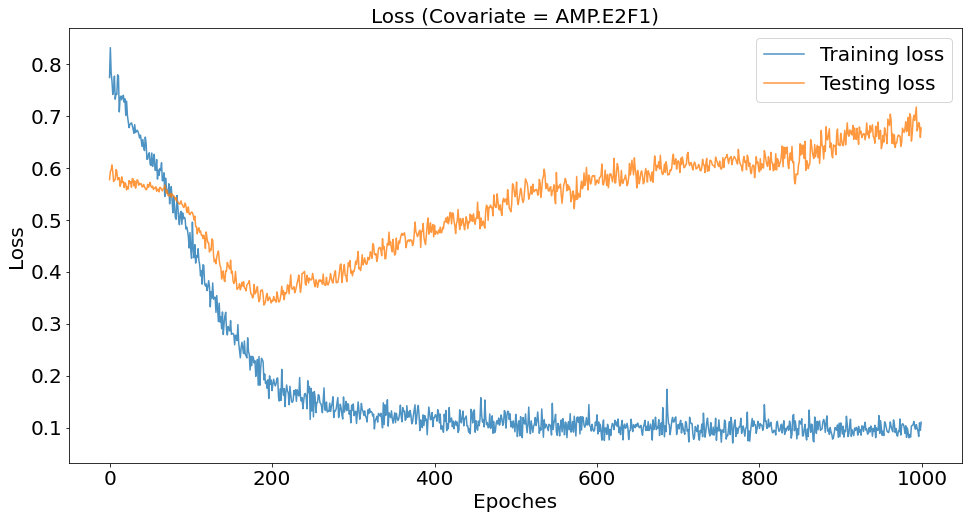

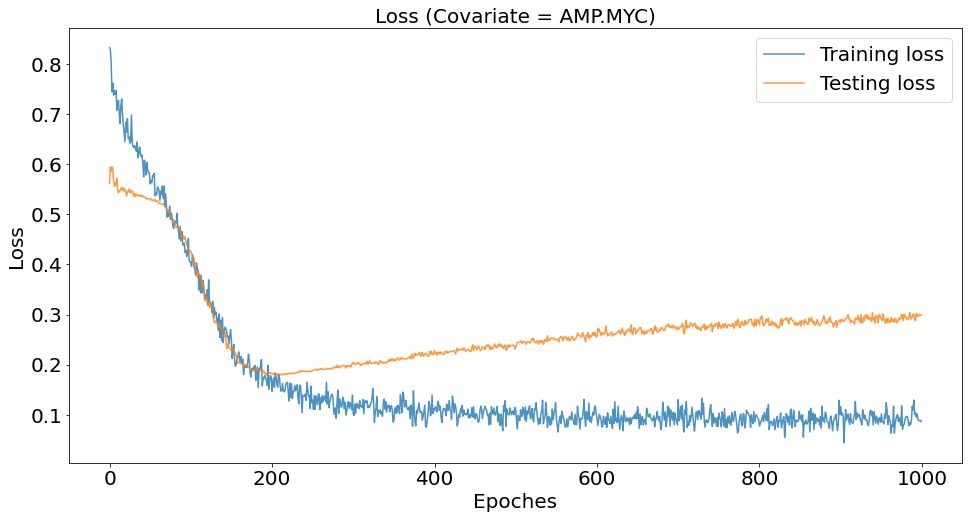

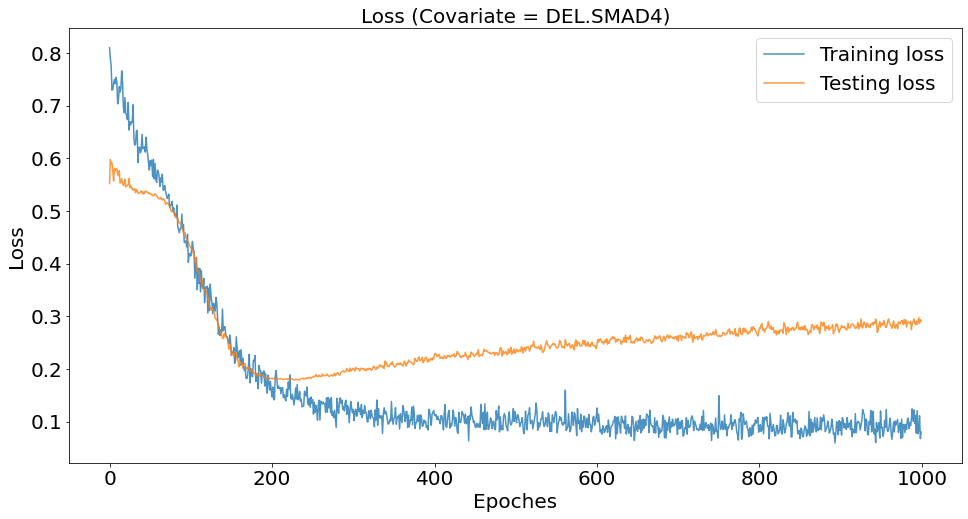

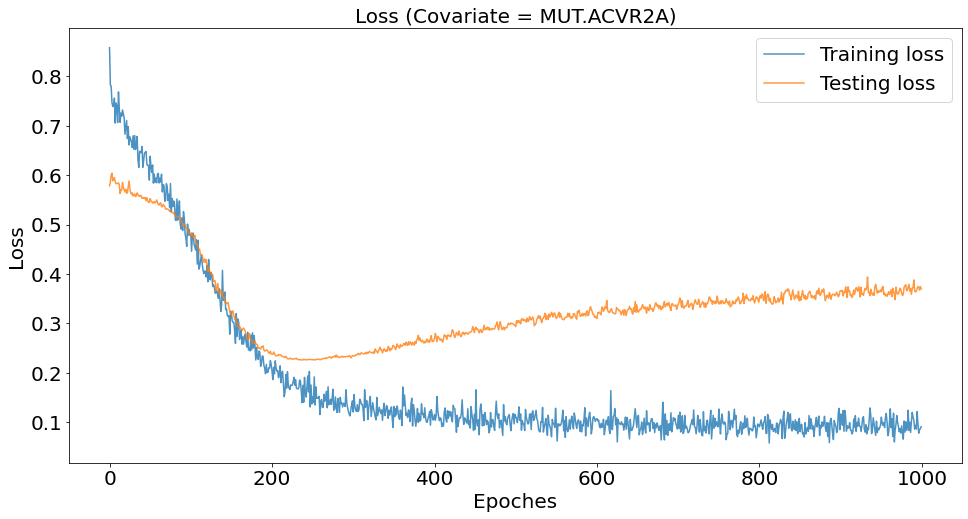

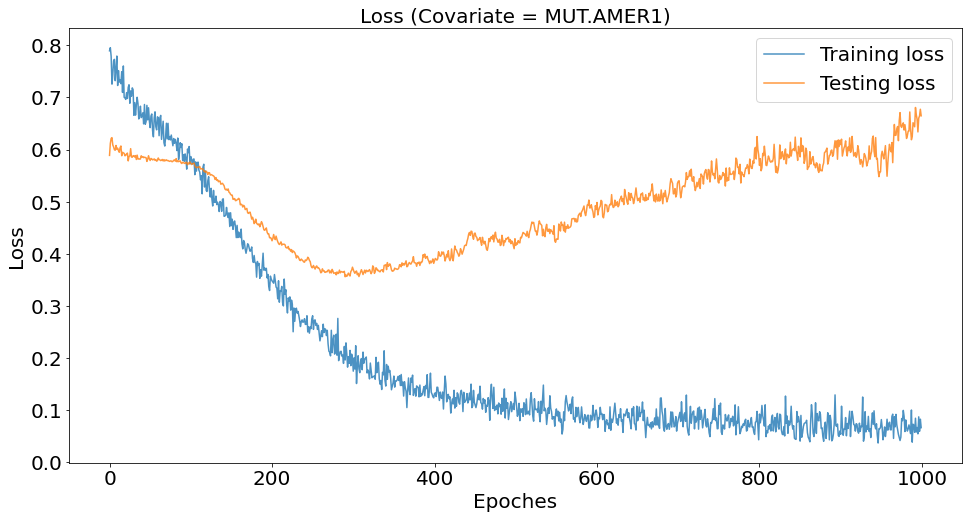

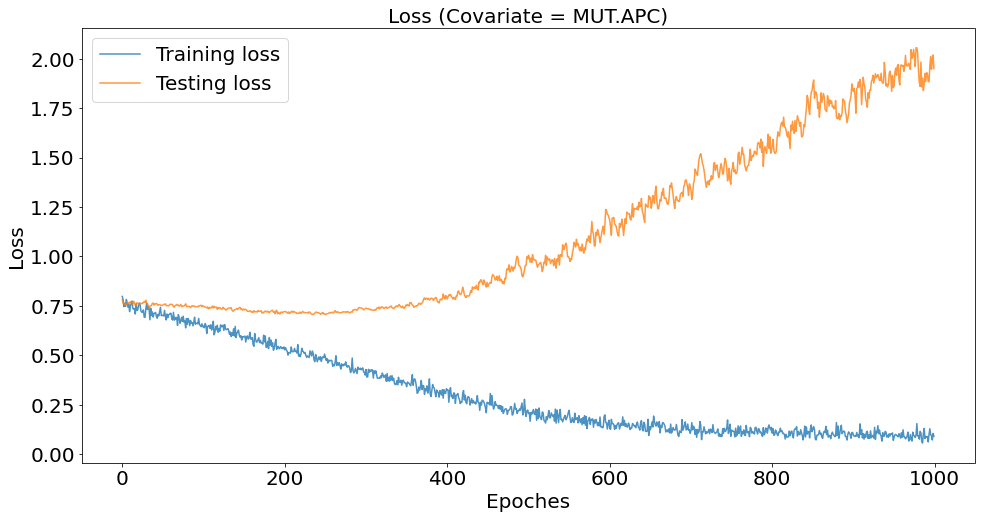

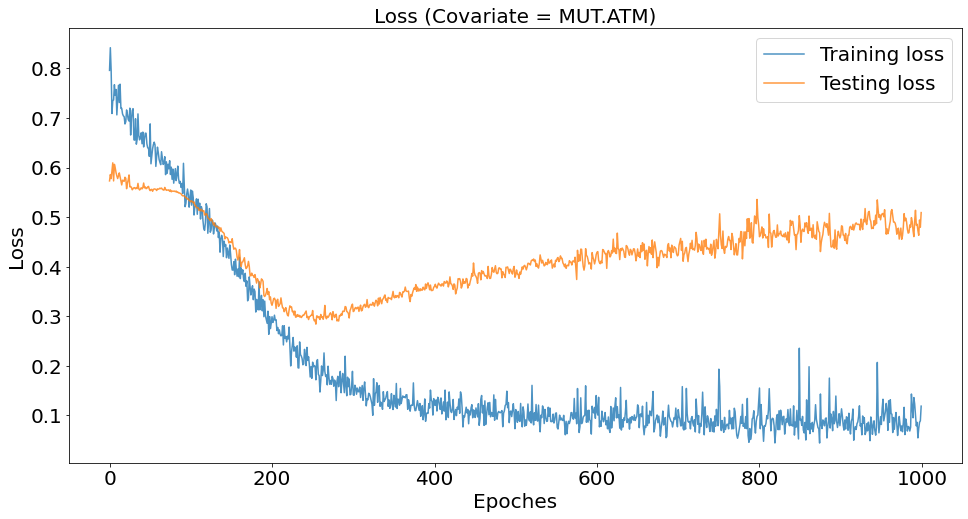

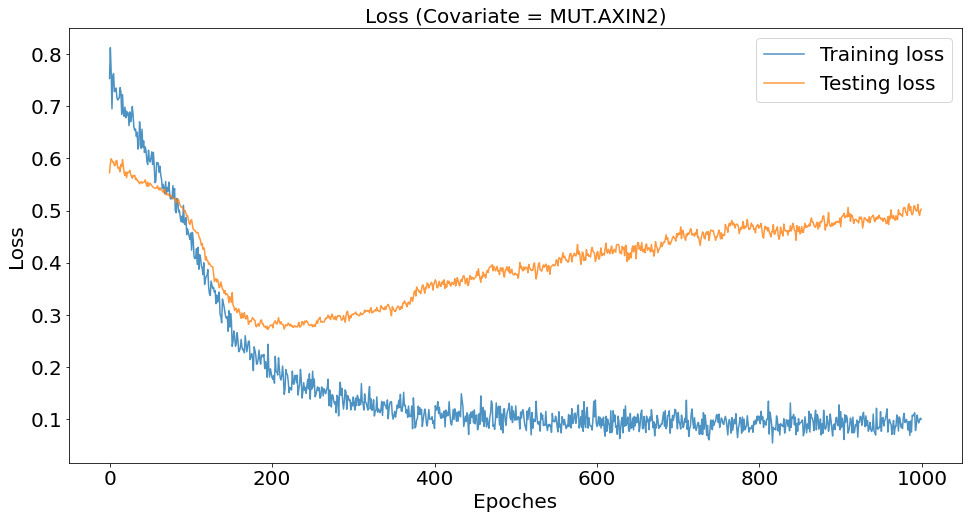

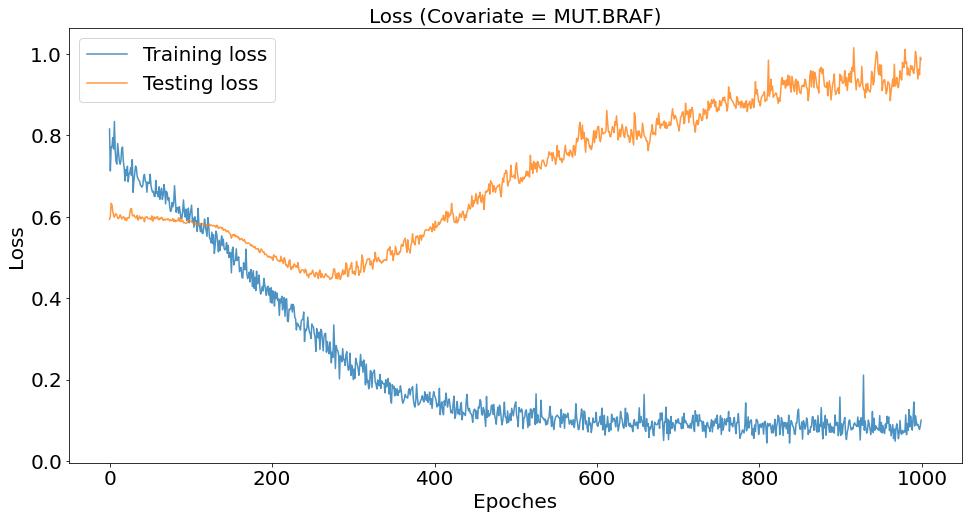

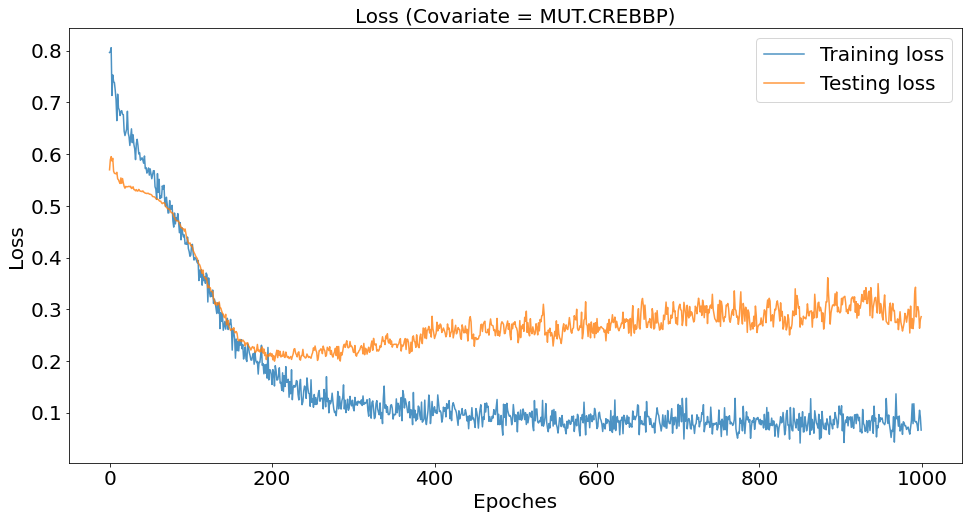

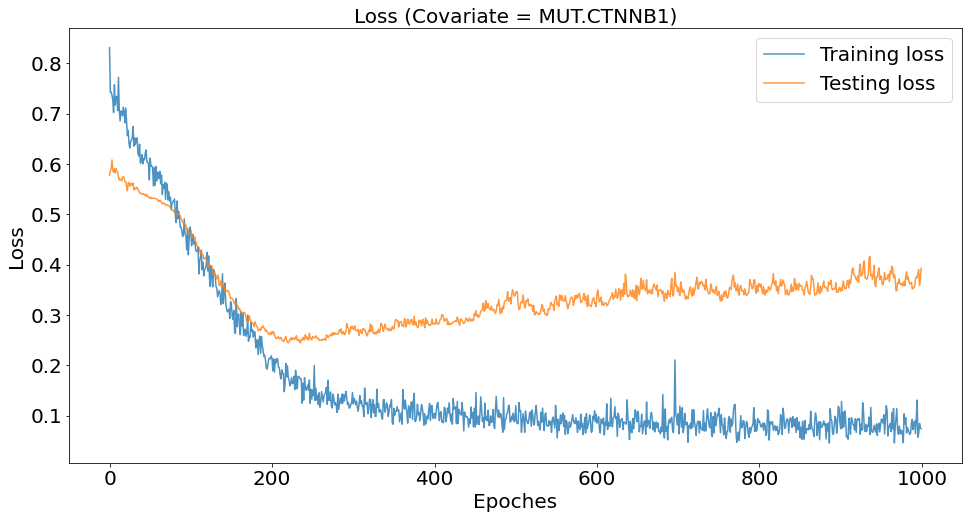

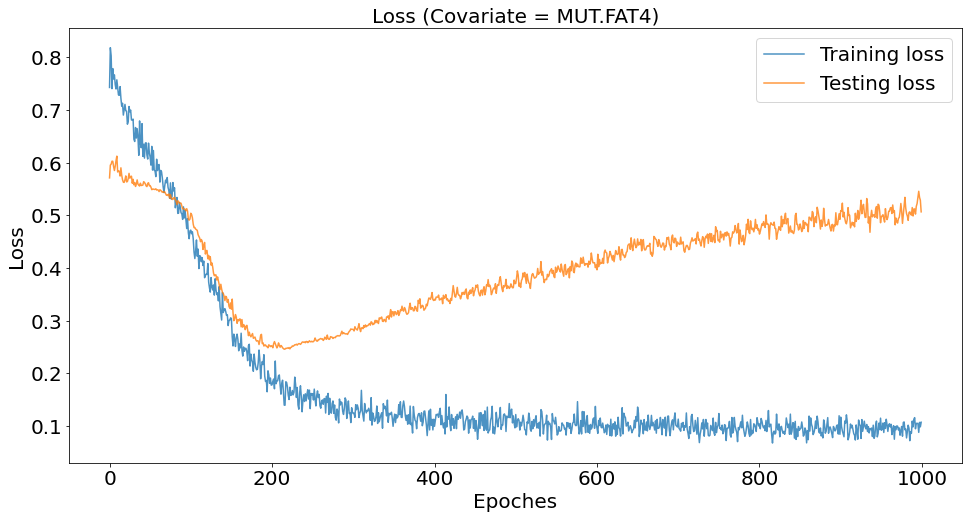

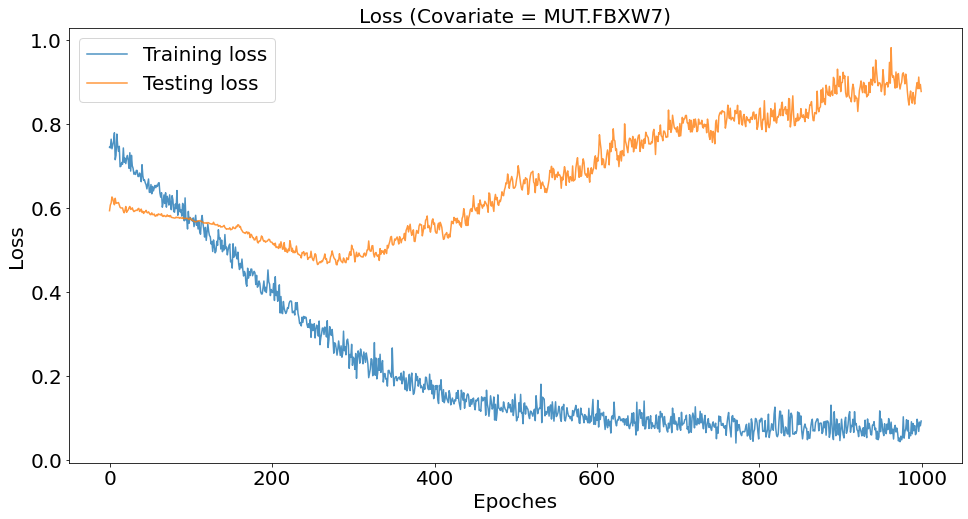

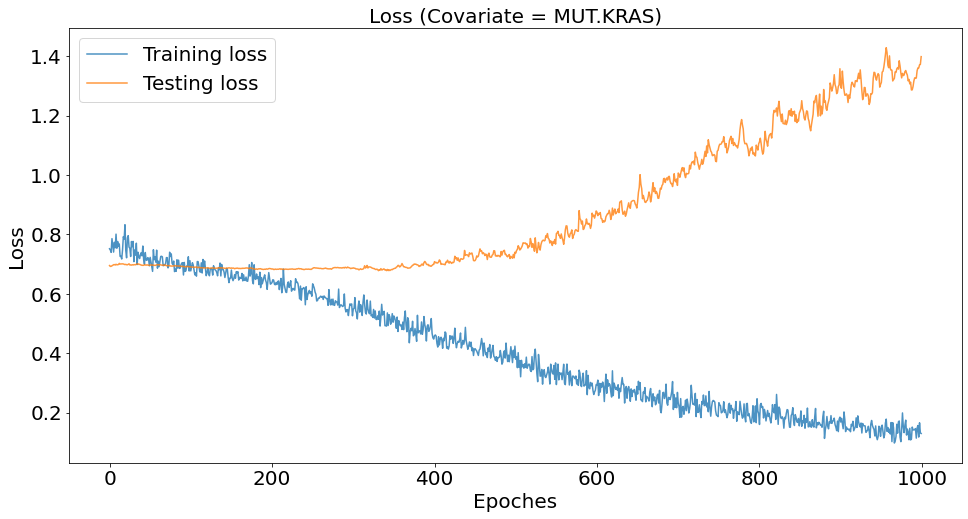

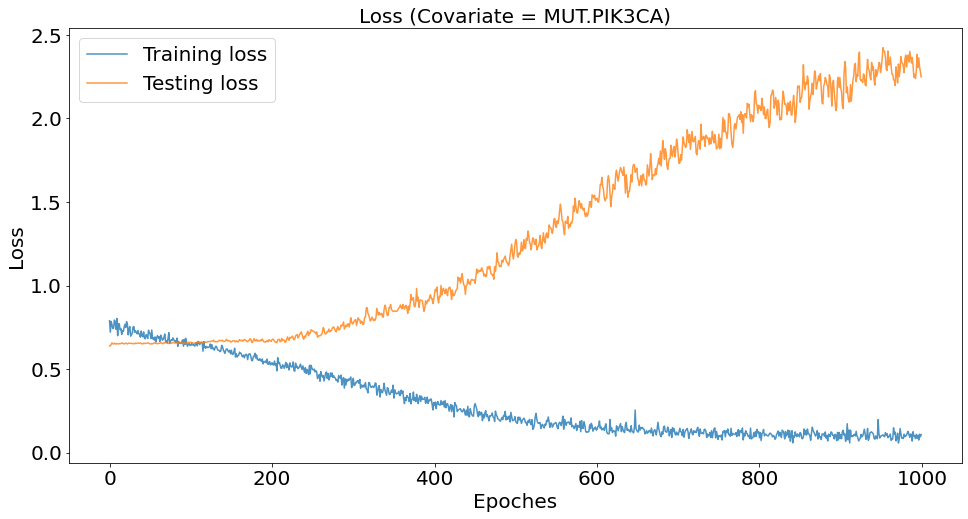

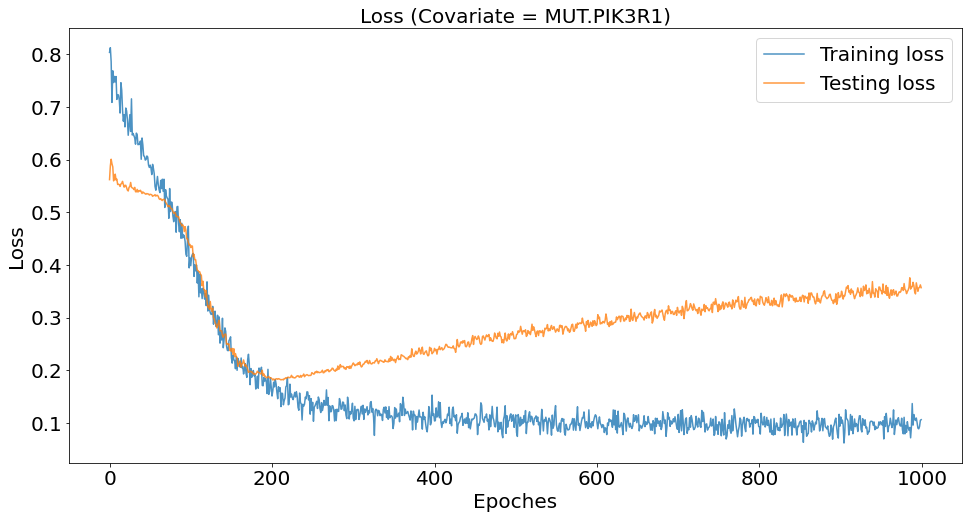

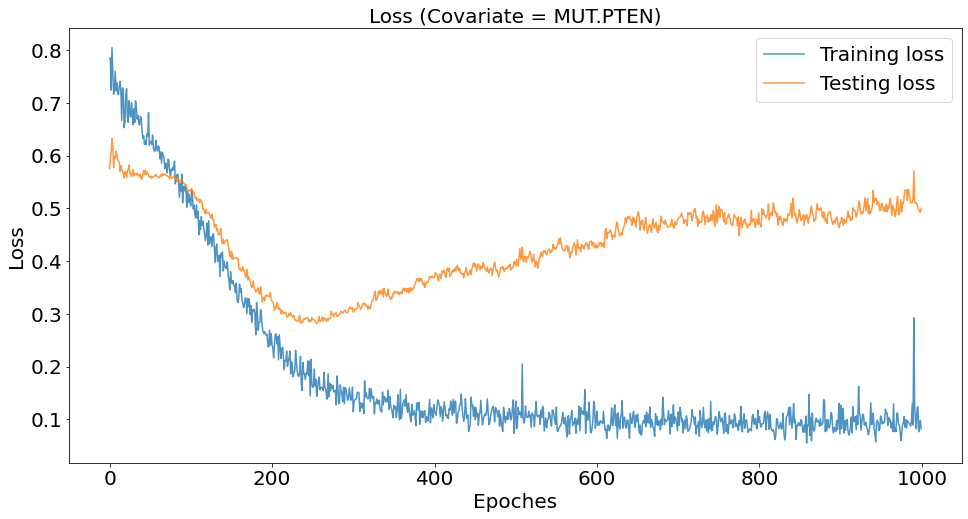

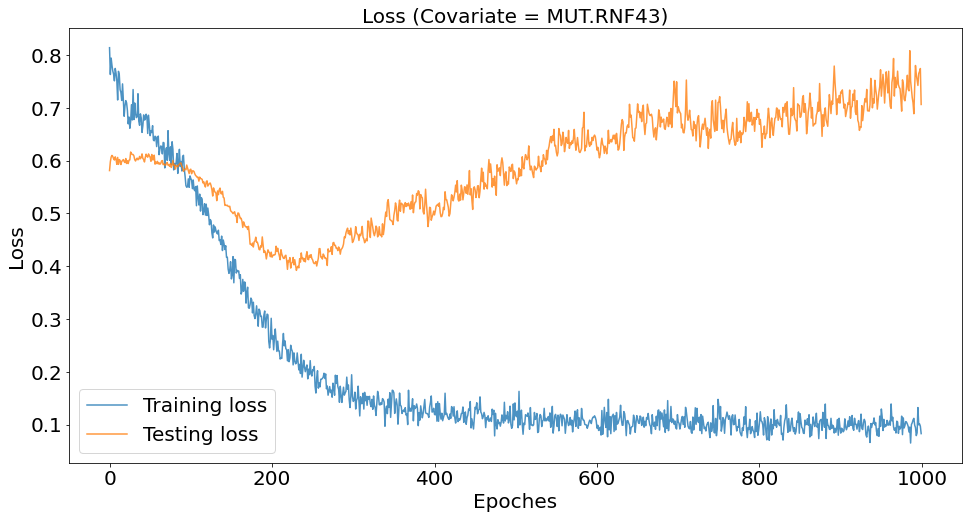

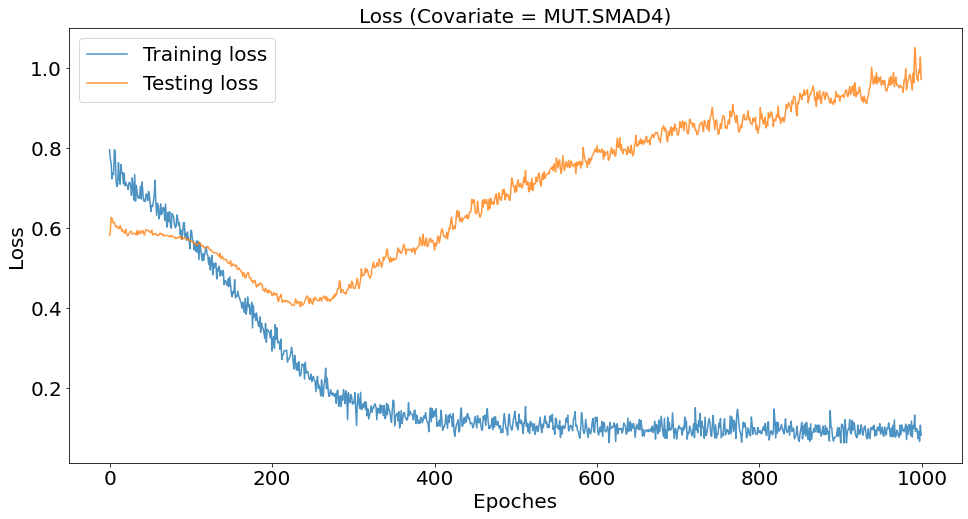

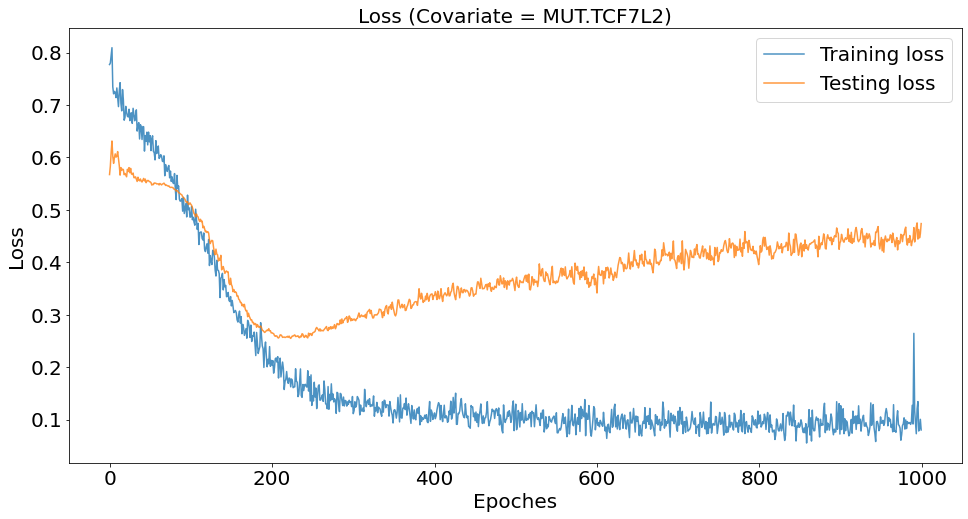

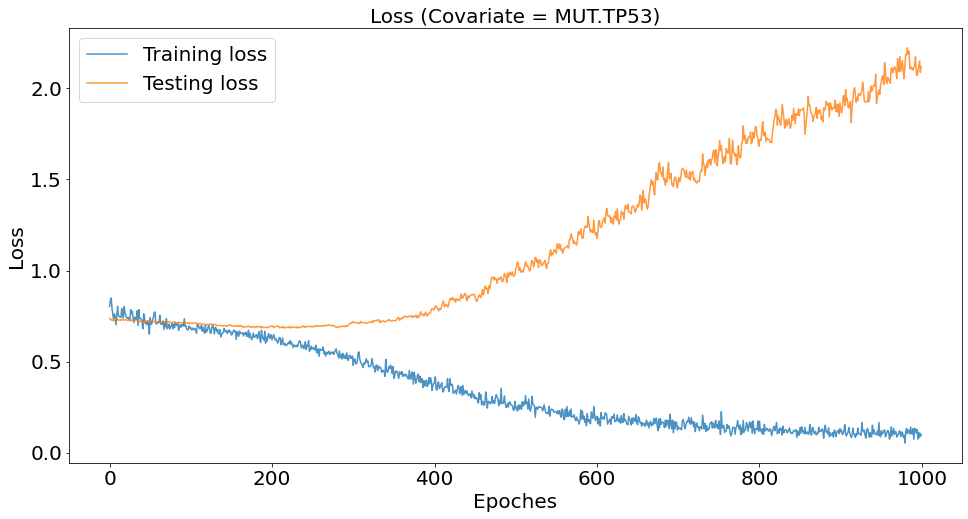

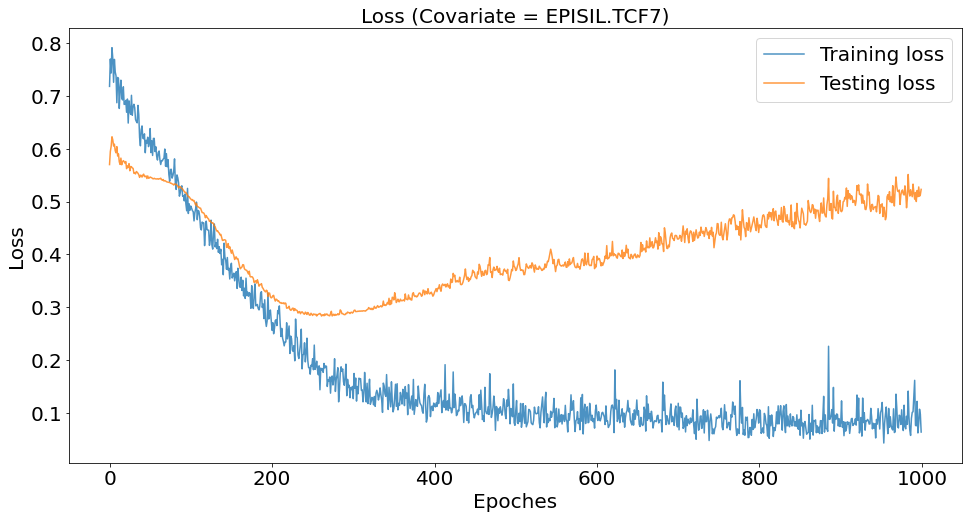

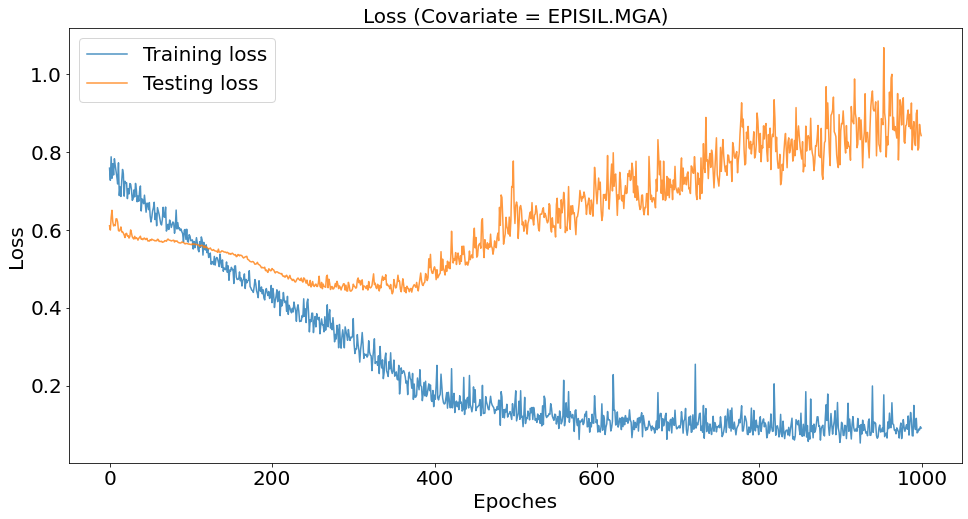

CPU times: user 21min 59s, sys: 54.7 s, total: 22min 53s
Wall time: 22min 13s


In [23]:
%%time
COAD_prediction_result_dict = train_mlp_all_cols('COAD', device=device, true_percentage_cutoff=0.04, dropout_rate=0.6, weight_decay=0.)

In [24]:
COAD_prediction_result_dict['auc']

{'AMP.E2F1': 0.6028368794326241,
 'AMP.MYC': 0.28125,
 'DEL.SMAD4': 0.3541666666666667,
 'MUT.ACVR2A': 0.6382978723404256,
 'MUT.AMER1': 0.5189393939393939,
 'MUT.APC': 0.6111111111111112,
 'MUT.ATM': 0.717391304347826,
 'MUT.AXIN2': 0.3404255319148936,
 'MUT.BRAF': 0.40863787375415284,
 'MUT.CREBBP': 0.5833333333333334,
 'MUT.CTNNB1': 0.4326241134751773,
 'MUT.FAT4': 0.36170212765957444,
 'MUT.FBXW7': 0.6960132890365448,
 'MUT.KRAS': 0.6038647342995169,
 'MUT.PIK3CA': 0.5142857142857142,
 'MUT.PIK3R1': 0.375,
 'MUT.PTEN': 0.6032608695652174,
 'MUT.RNF43': 0.5644444444444444,
 'MUT.SMAD4': 0.3409090909090909,
 'MUT.TCF7L2': 0.7065217391304348,
 'MUT.TP53': 0.5349999999999999,
 'EPISIL.TCF7': 0.41304347826086957,
 'EPISIL.MGA': 0.6016260162601625}

In [25]:
len(list(COAD_prediction_result_dict['auc'].keys()))

23

In [26]:
np.sort(list(COAD_prediction_result_dict['auc'].values()))[::-1]

array([0.7173913 , 0.70652174, 0.69601329, 0.63829787, 0.61111111,
       0.60386473, 0.60326087, 0.60283688, 0.60162602, 0.58333333,
       0.56444444, 0.535     , 0.51893939, 0.51428571, 0.43262411,
       0.41304348, 0.40863787, 0.375     , 0.36170213, 0.35416667,
       0.34090909, 0.34042553, 0.28125   ])

### STAD

(380, 30)


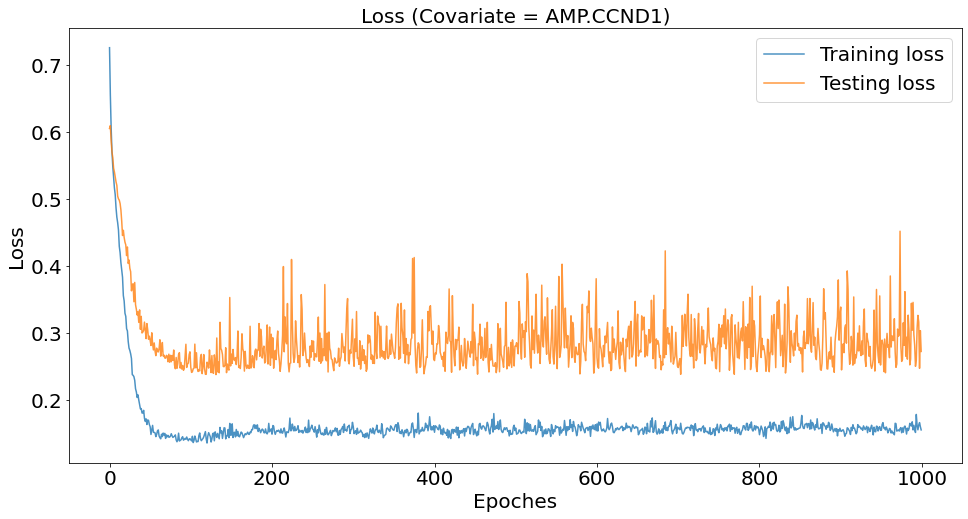

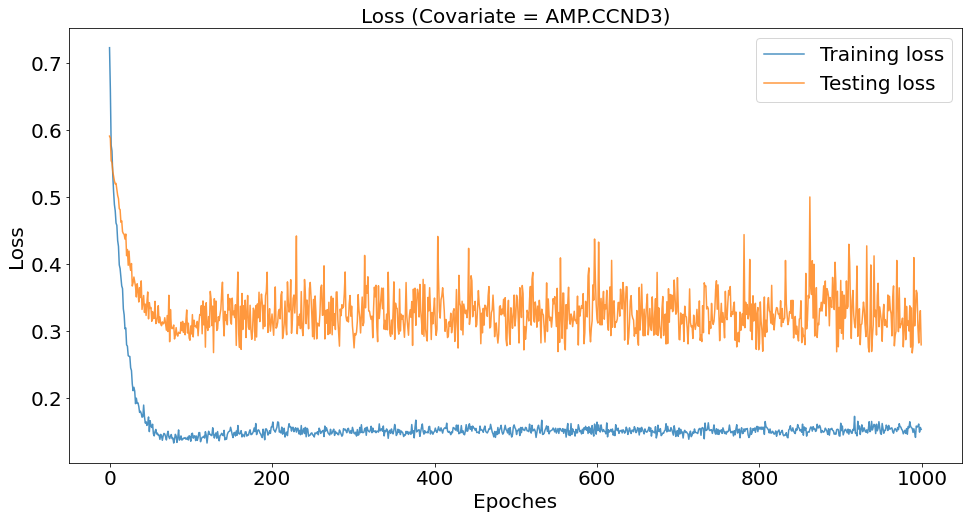

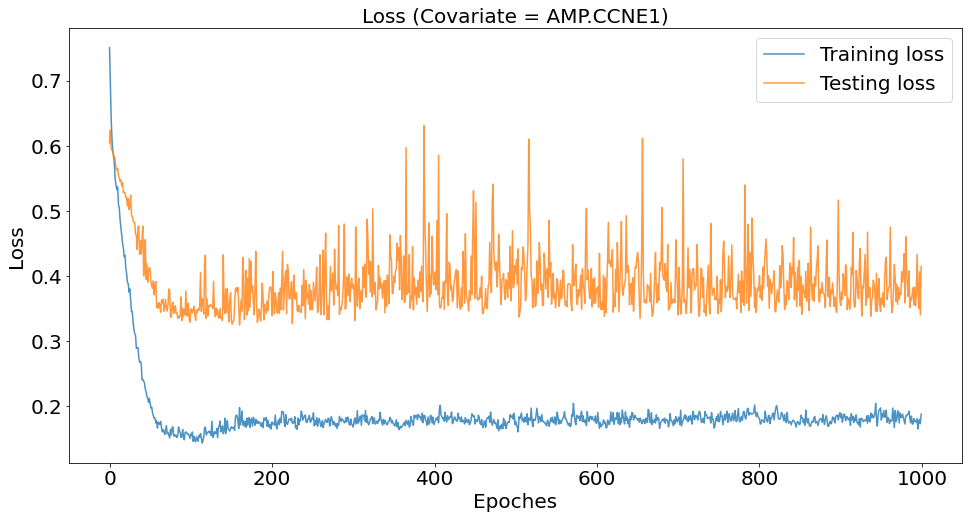

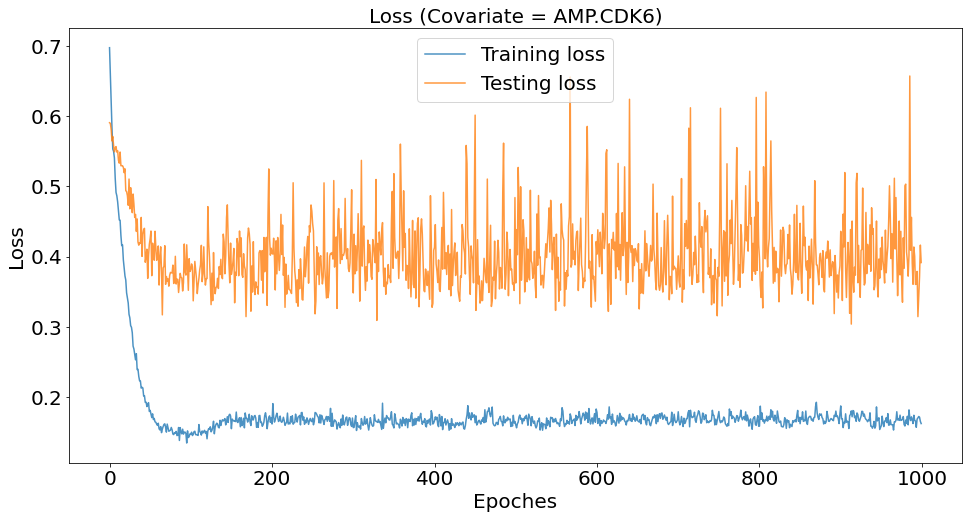

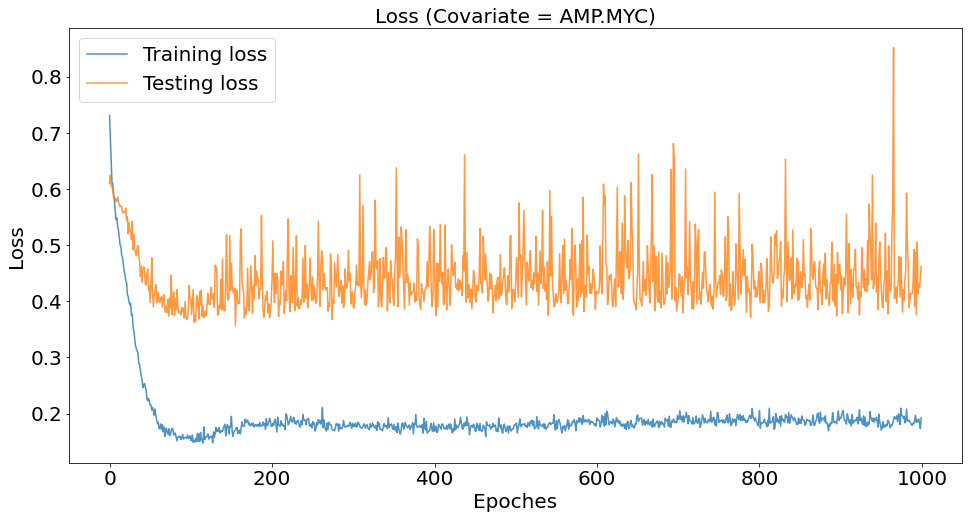

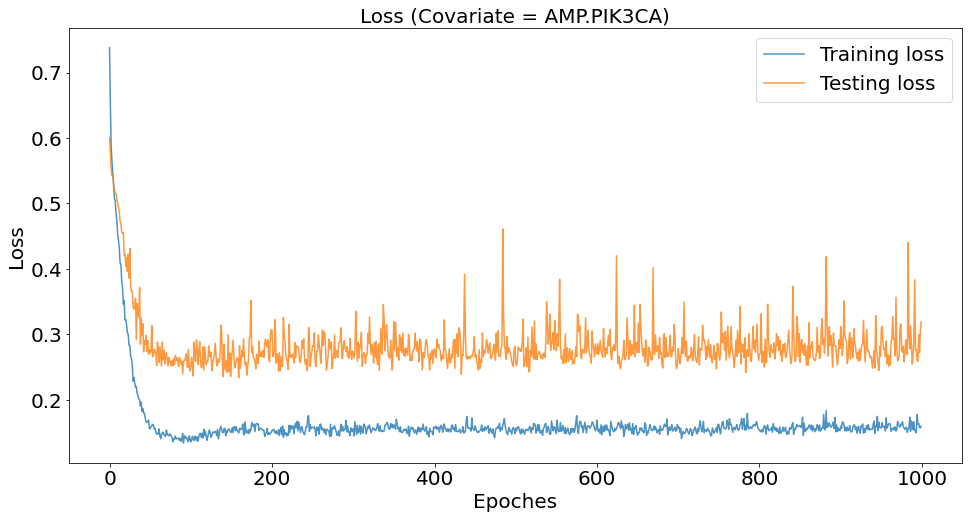

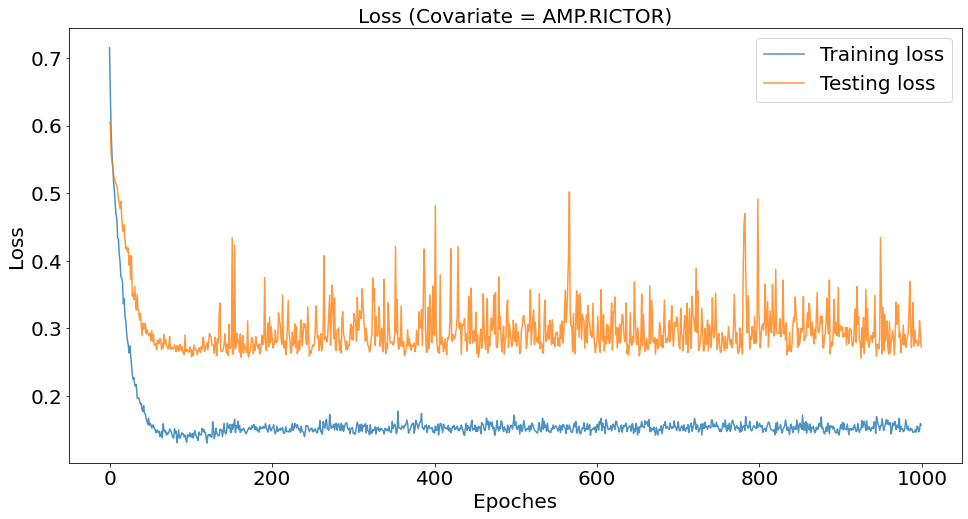

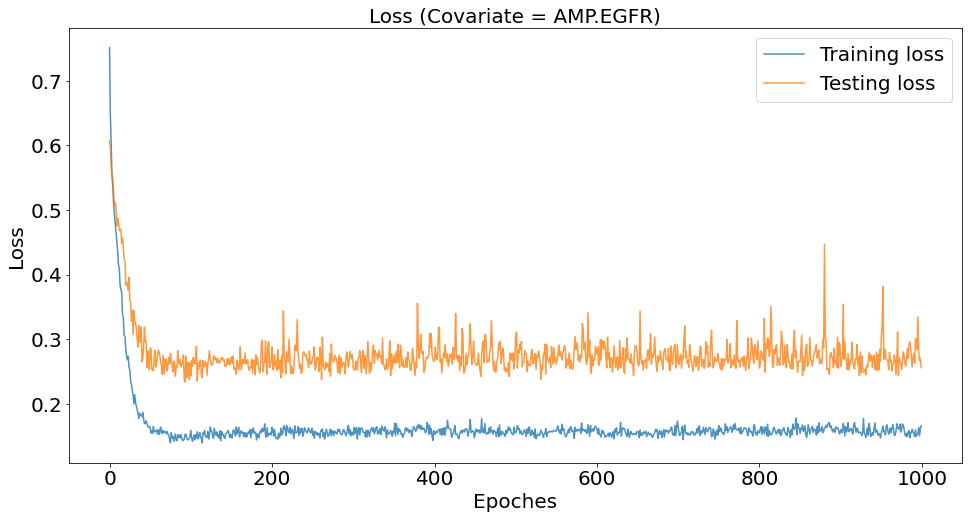

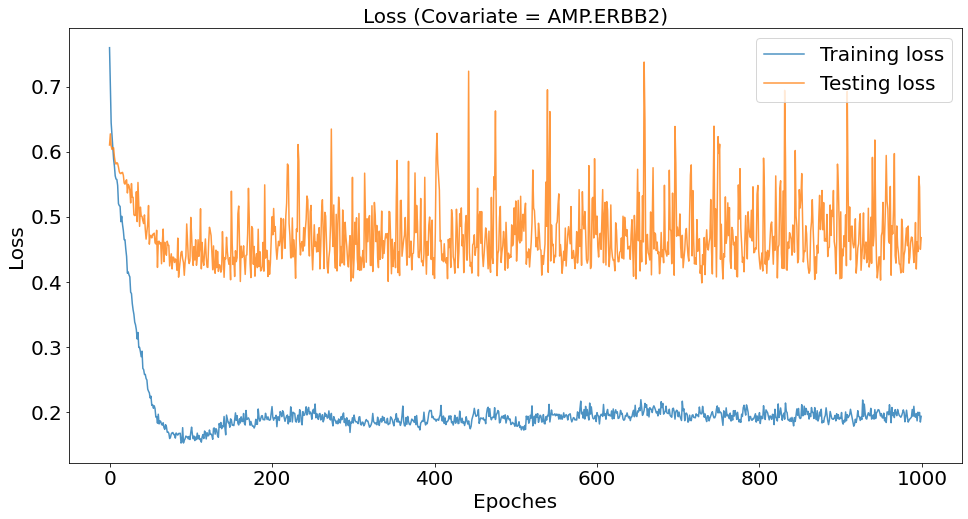

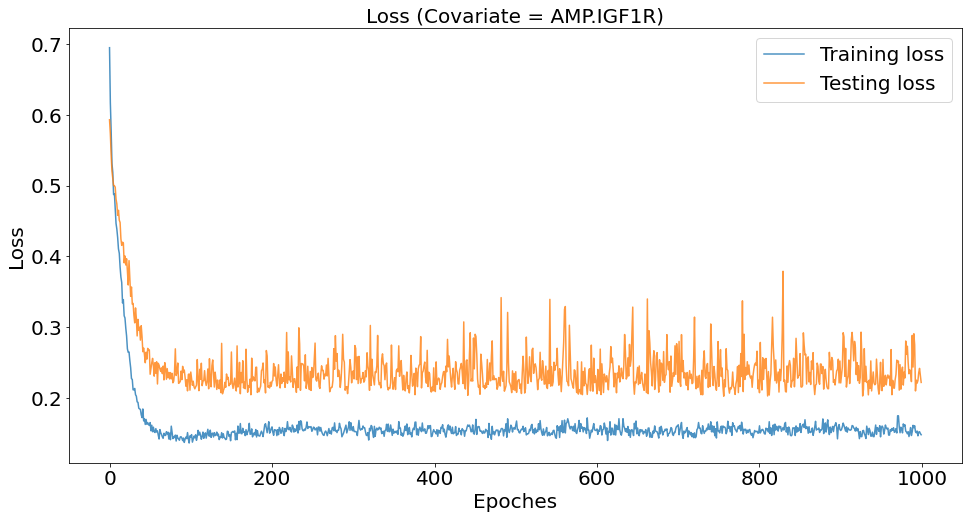

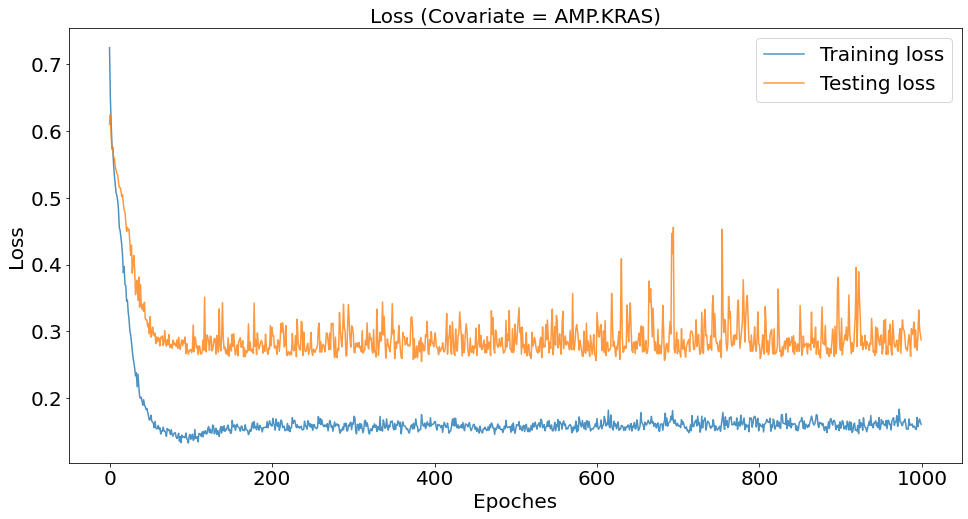

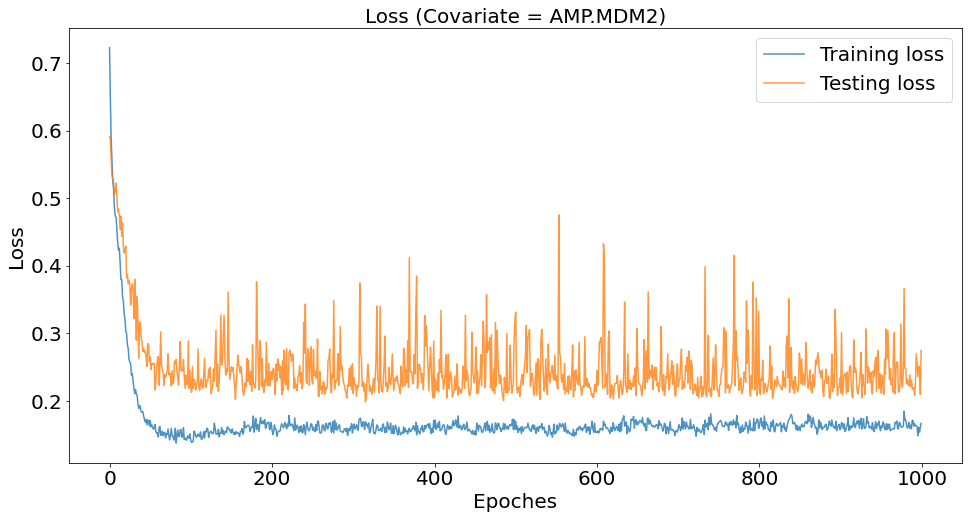

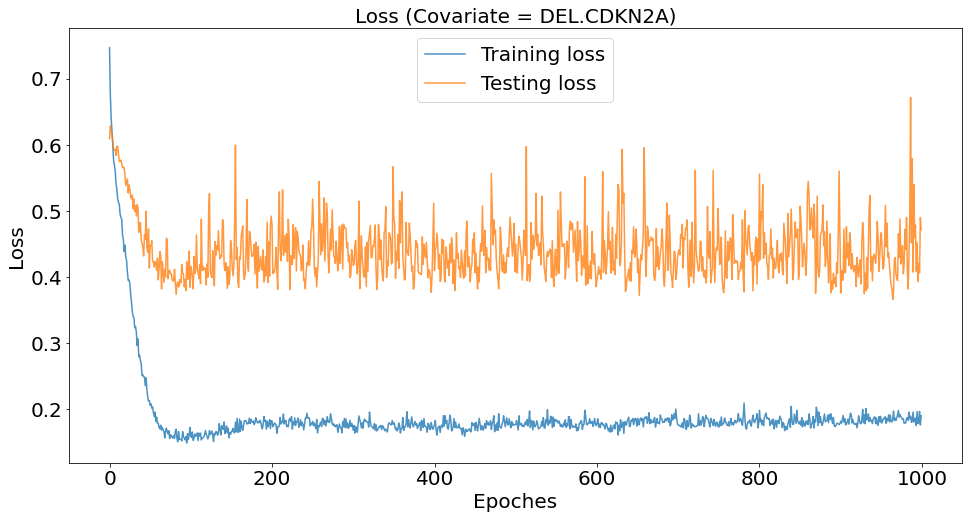

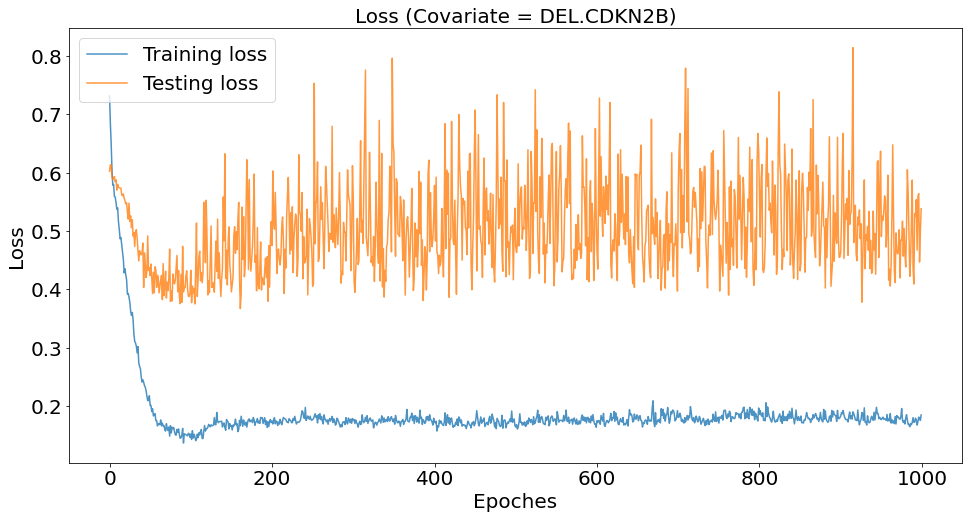

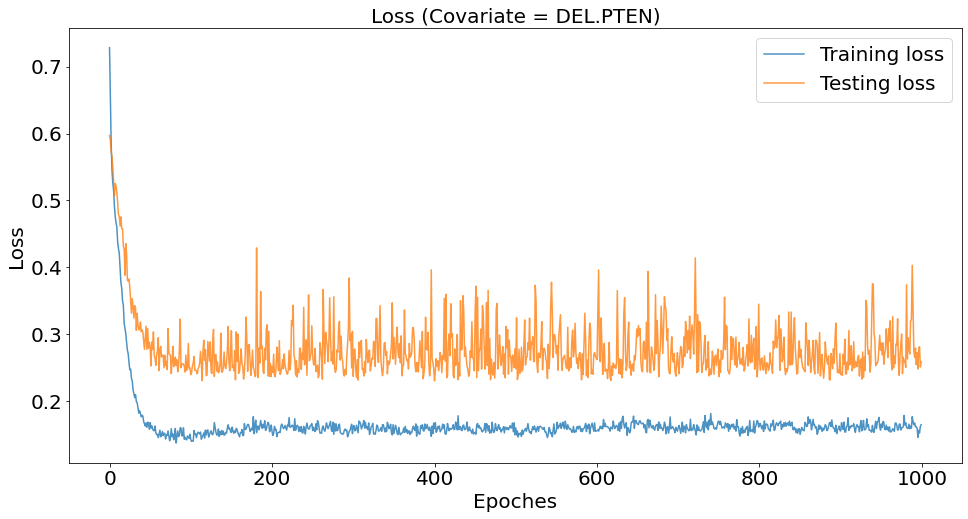

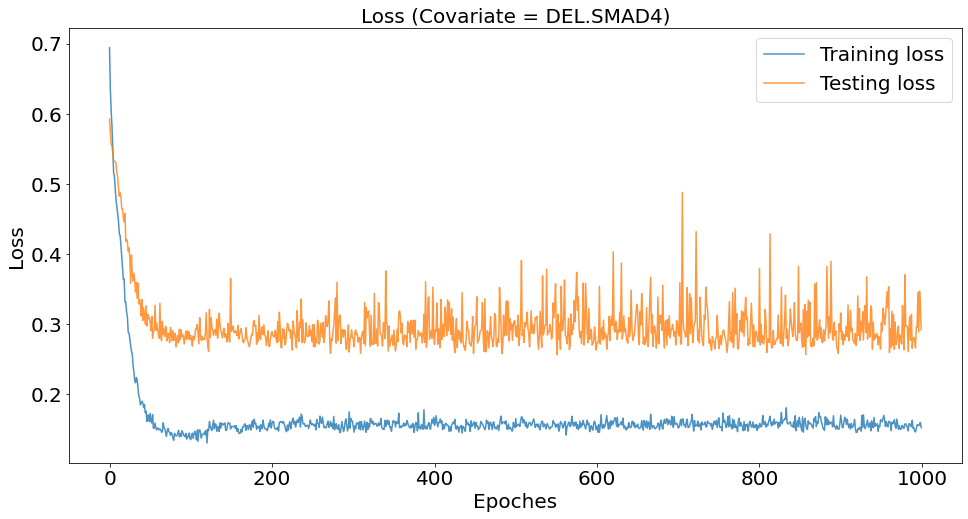

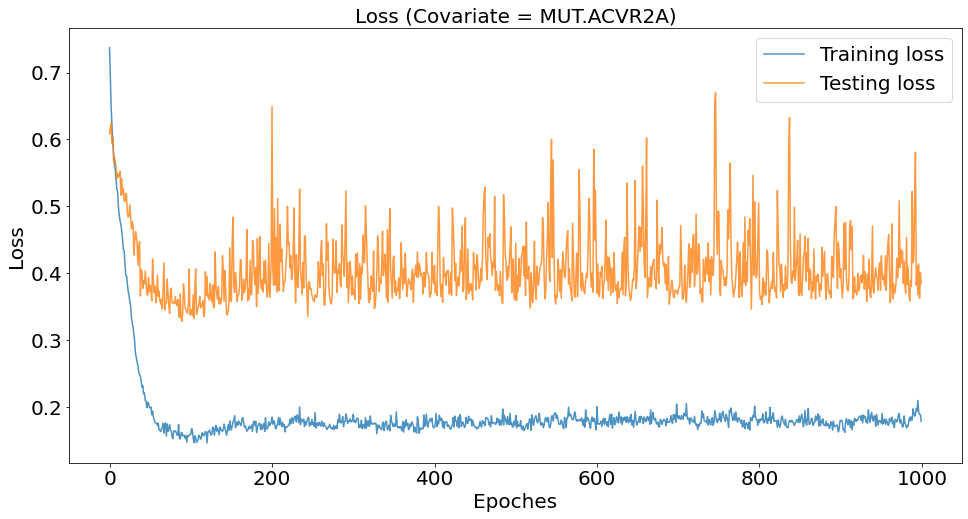

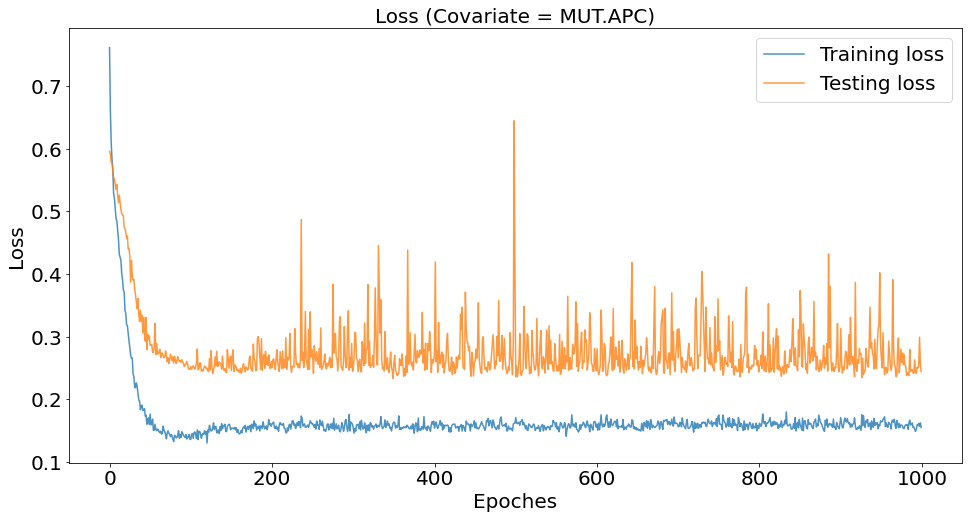

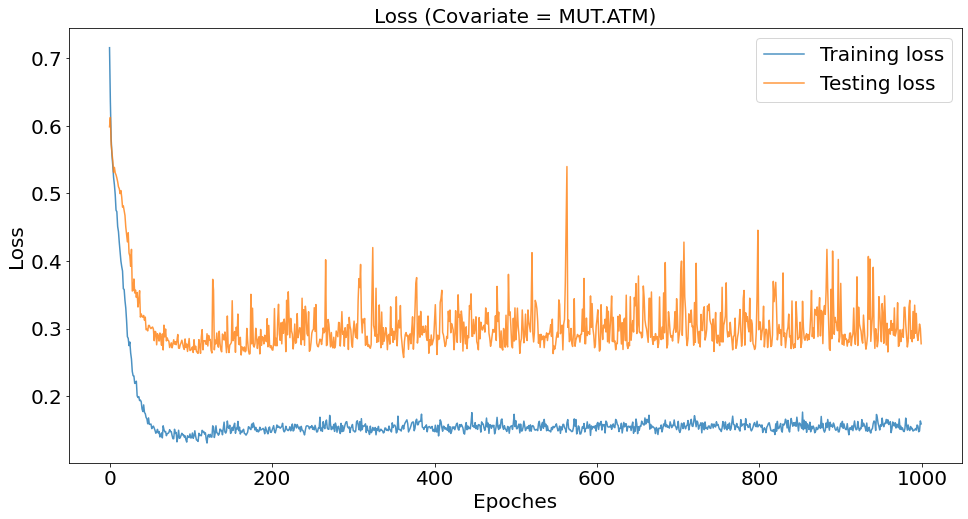

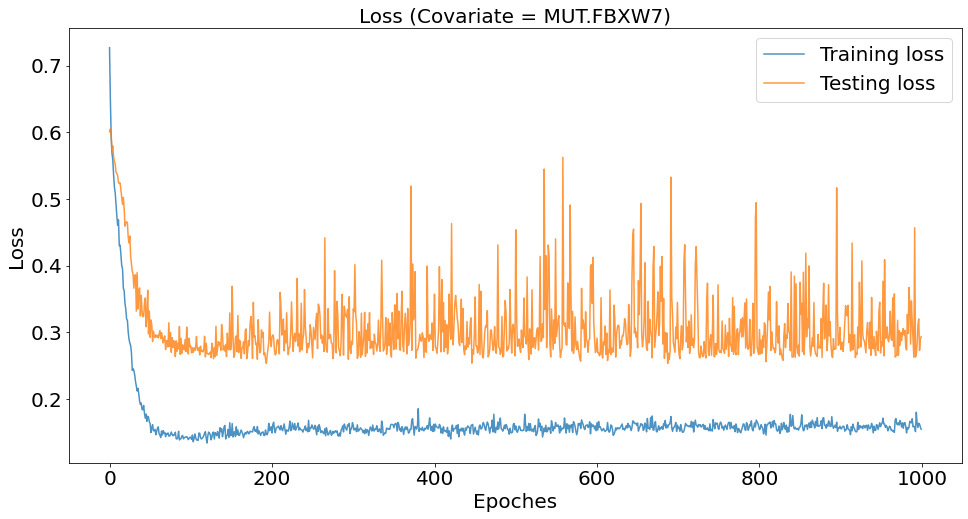

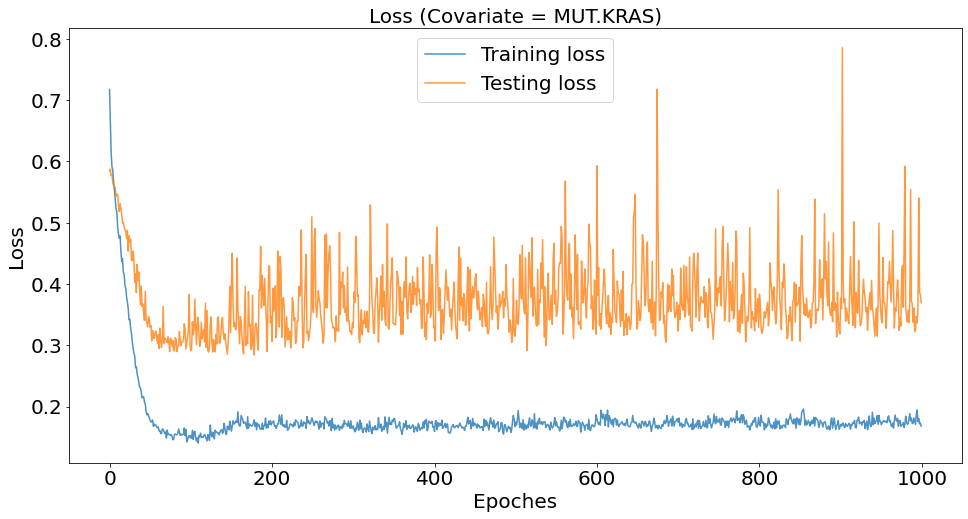

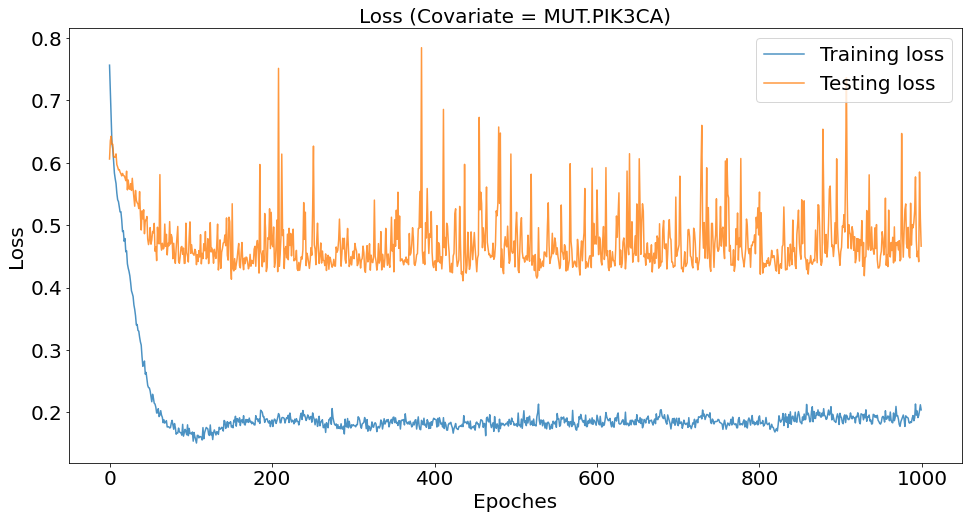

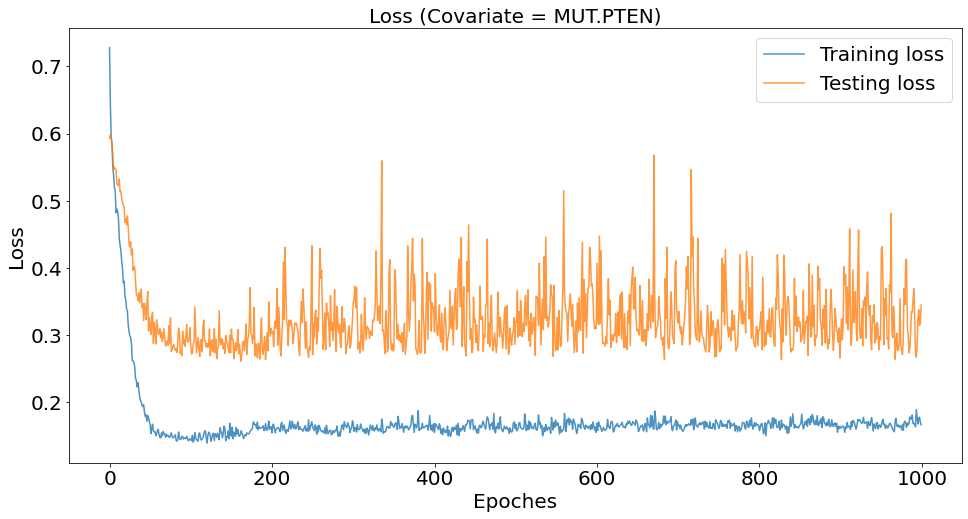

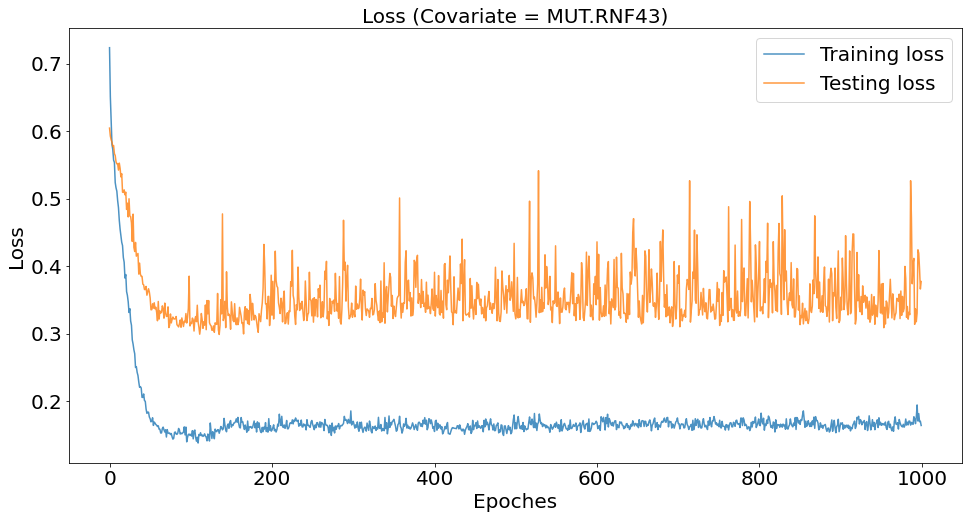

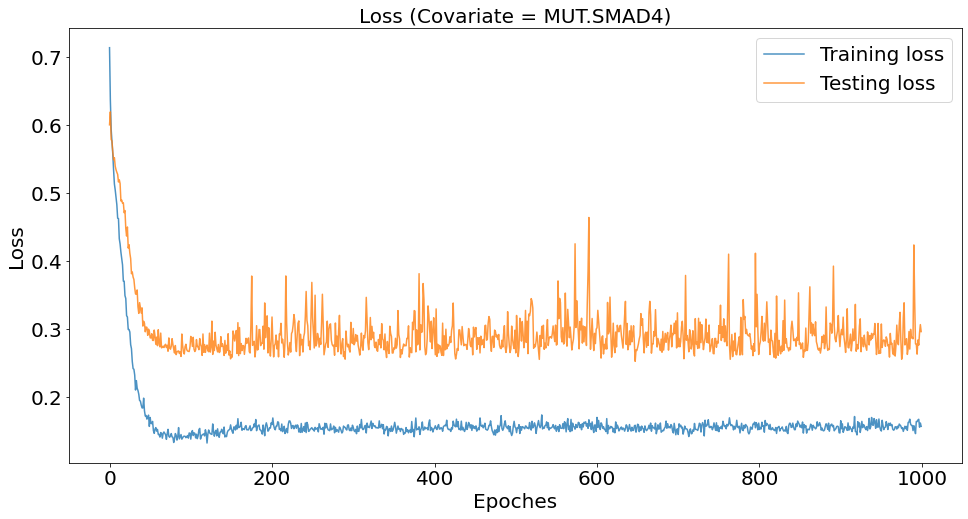

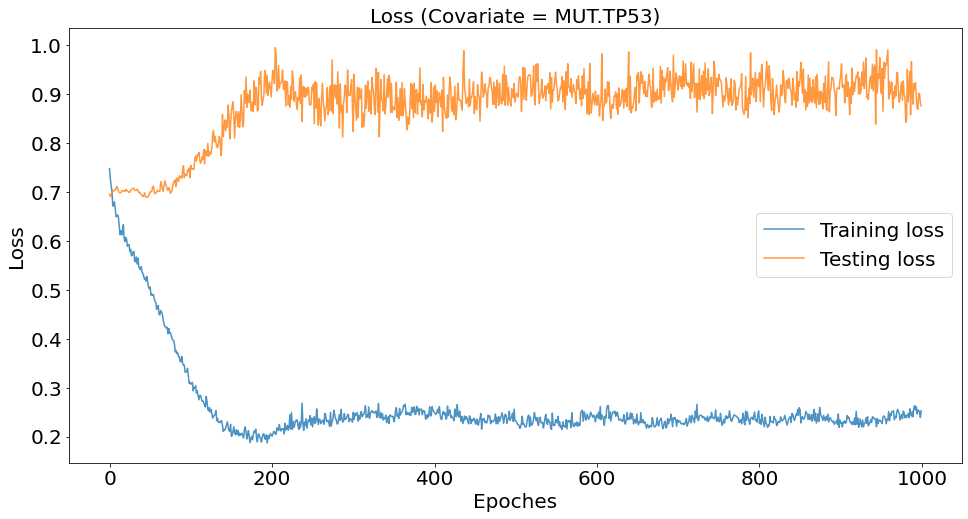

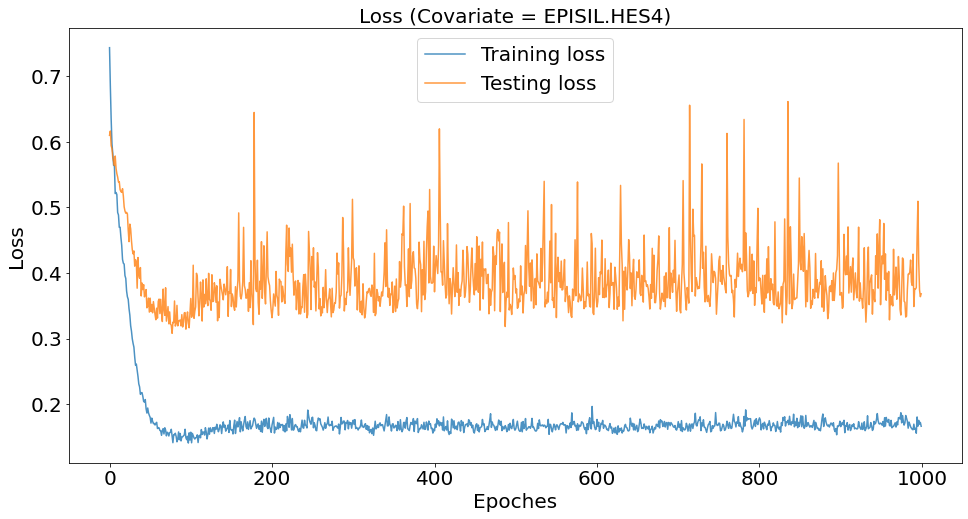

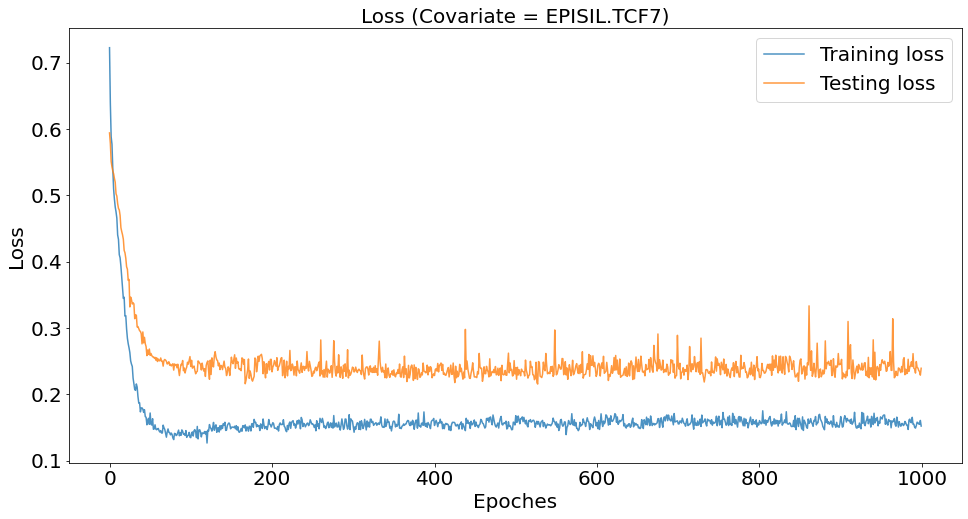

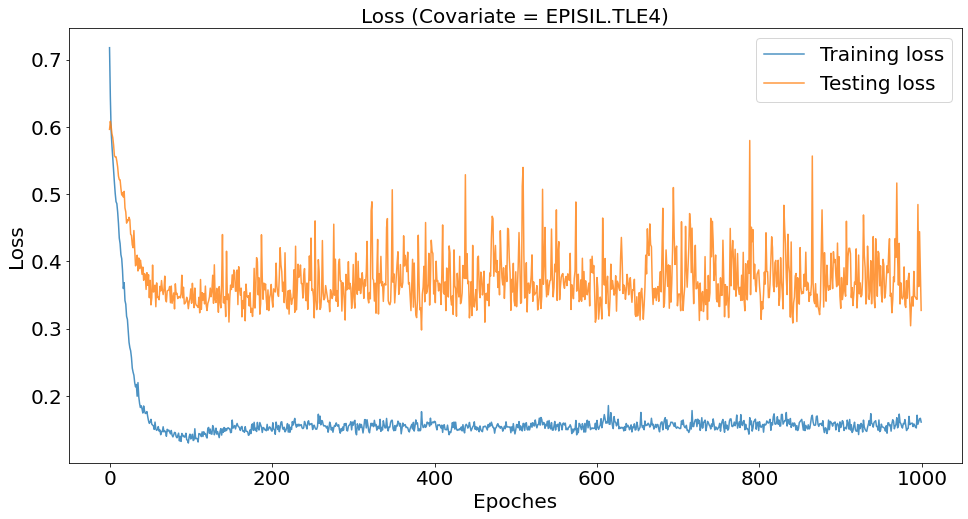

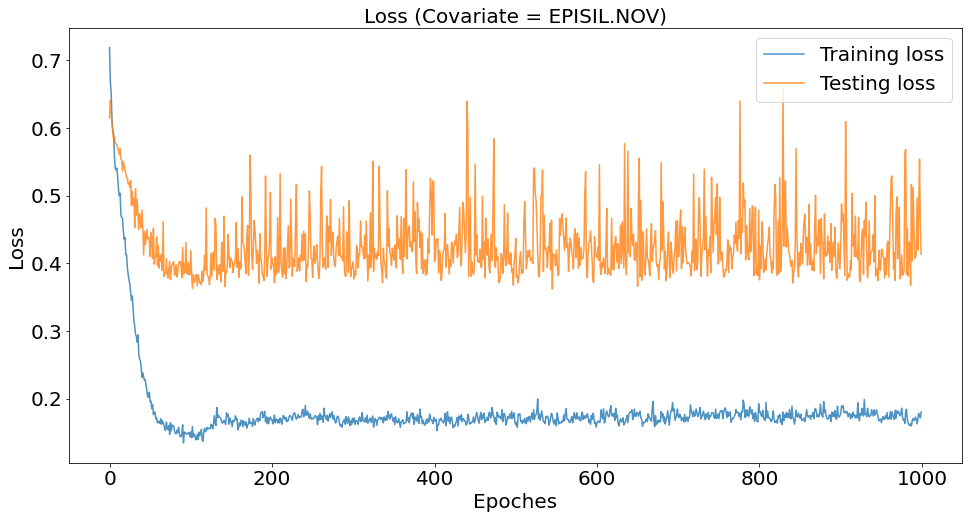

CPU times: user 45min 43s, sys: 1min 46s, total: 47min 30s
Wall time: 46min 11s


In [27]:
%%time
STAD_prediction_result_dict = train_mlp_all_cols('STAD', device=device, true_percentage_cutoff=0.04, dropout_rate=0.2, weight_decay=0.1)

In [28]:
STAD_prediction_result_dict['auc']

{'AMP.CCND1': 0.6690140845070424,
 'AMP.CCND3': 0.4140845070422535,
 'AMP.CCNE1': 0.5119485294117647,
 'AMP.CDK6': 0.5166666666666667,
 'AMP.MYC': 0.5298507462686568,
 'AMP.PIK3CA': 0.65625,
 'AMP.RICTOR': 0.6380281690140845,
 'AMP.EGFR': 0.6440972222222222,
 'AMP.ERBB2': 0.406060606060606,
 'AMP.IGF1R': 0.2054794520547945,
 'AMP.KRAS': 0.6985915492957746,
 'AMP.MDM2': 0.3904109589041096,
 'DEL.CDKN2A': 0.4295190713101161,
 'DEL.CDKN2B': 0.4369817578772802,
 'DEL.PTEN': 0.234375,
 'DEL.SMAD4': 0.5436619718309859,
 'MUT.ACVR2A': 0.6544117647058824,
 'MUT.APC': 0.48873239436619725,
 'MUT.ATM': 0.5169014084507042,
 'MUT.FBXW7': 0.5943661971830986,
 'MUT.KRAS': 0.35833333333333334,
 'MUT.PIK3CA': 0.6868489583333333,
 'MUT.PTEN': 0.37746478873239436,
 'MUT.RNF43': 0.5714285714285715,
 'MUT.SMAD4': 0.6098591549295775,
 'MUT.TP53': 0.42569444444444443,
 'EPISIL.HES4': 0.7536231884057971,
 'EPISIL.TCF7': 0.7591549295774648,
 'EPISIL.TLE4': 0.34761904761904766,
 'EPISIL.NOV': 0.37893864013267}

In [29]:
len(list(STAD_prediction_result_dict['auc'].keys()))

30

In [30]:
np.sort(list(STAD_prediction_result_dict['auc'].values()))[::-1]

array([0.75915493, 0.75362319, 0.69859155, 0.68684896, 0.66901408,
       0.65625   , 0.65441176, 0.64409722, 0.63802817, 0.60985915,
       0.5943662 , 0.57142857, 0.54366197, 0.52985075, 0.51690141,
       0.51666667, 0.51194853, 0.48873239, 0.43698176, 0.42951907,
       0.42569444, 0.41408451, 0.40606061, 0.39041096, 0.37893864,
       0.37746479, 0.35833333, 0.34761905, 0.234375  , 0.20547945])

### LUAD

(502, 18)


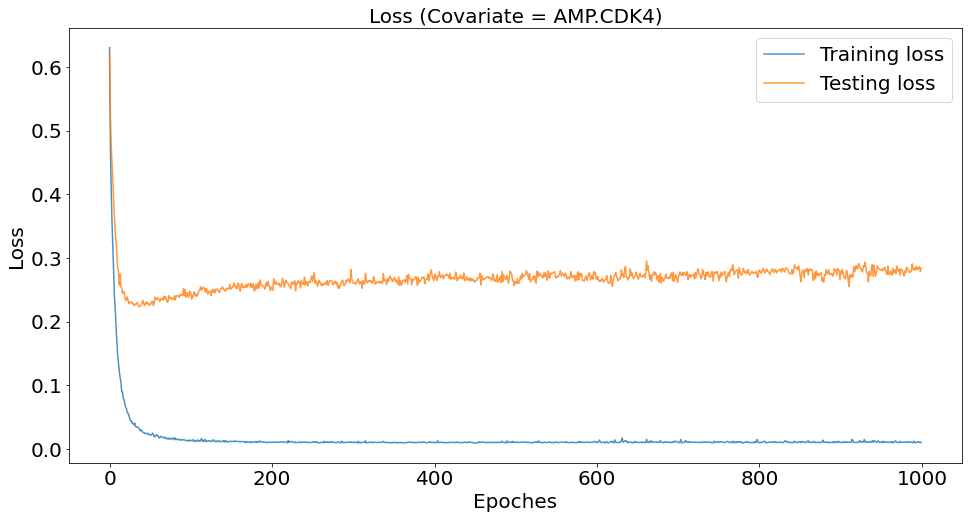

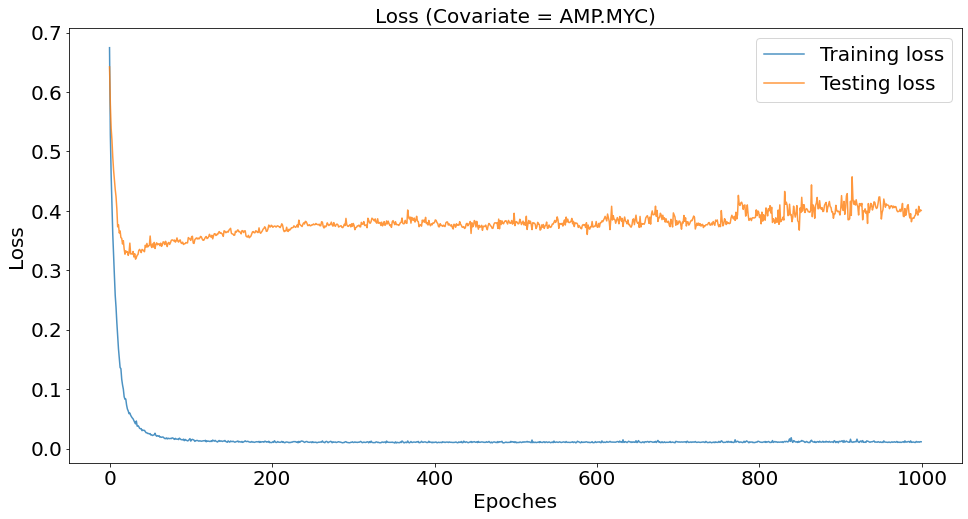

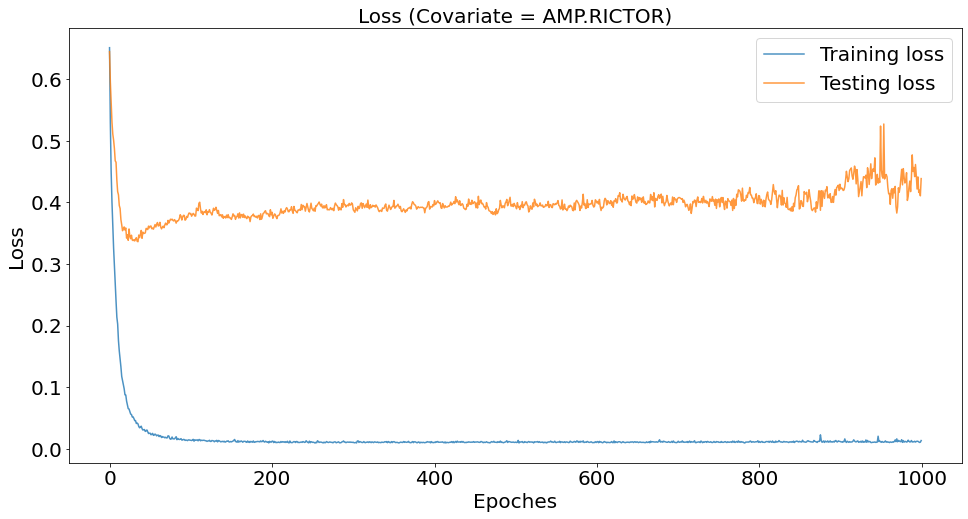

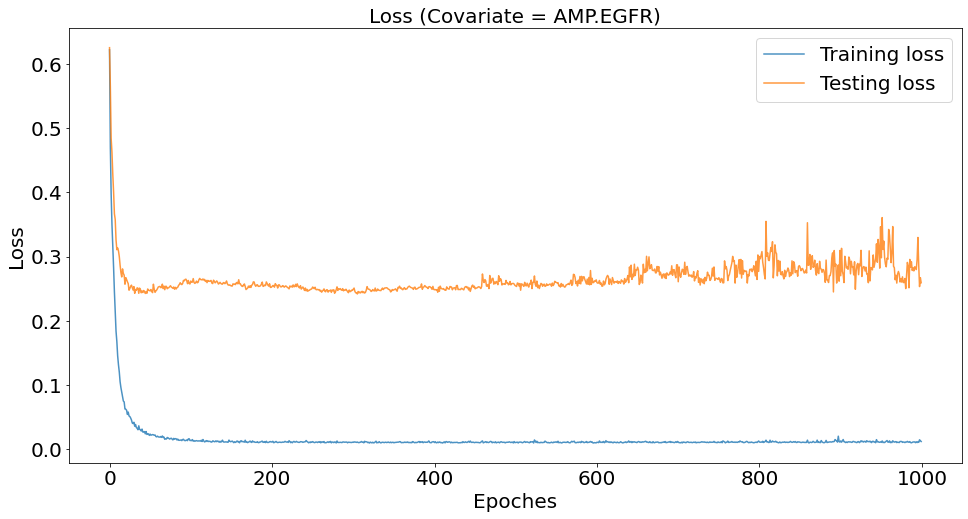

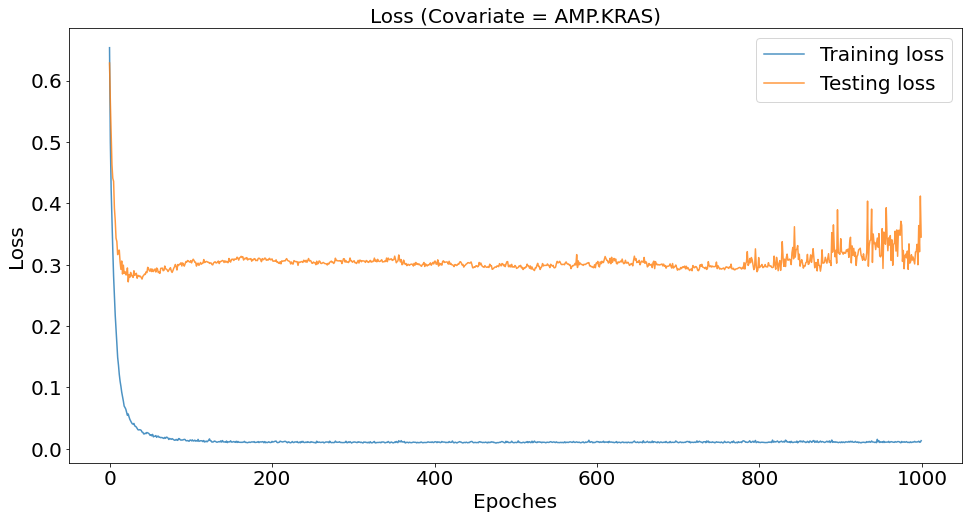

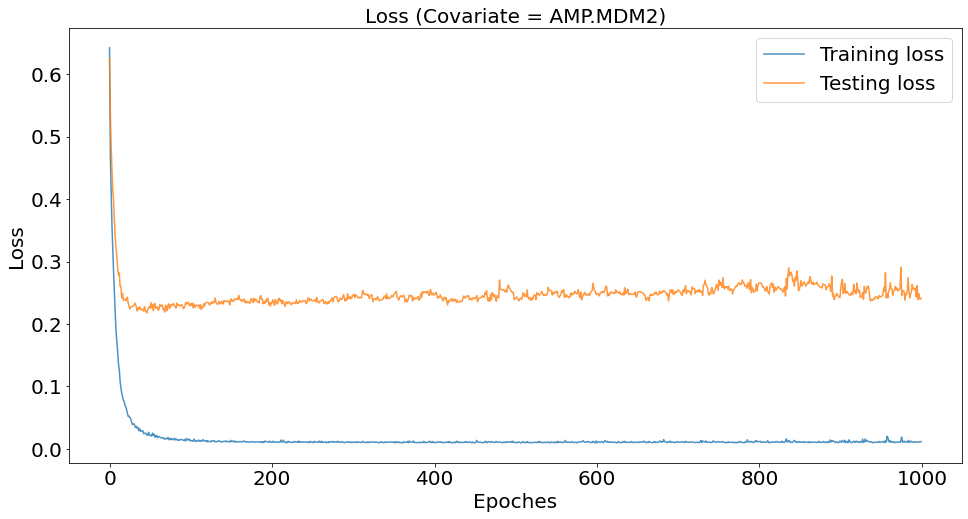

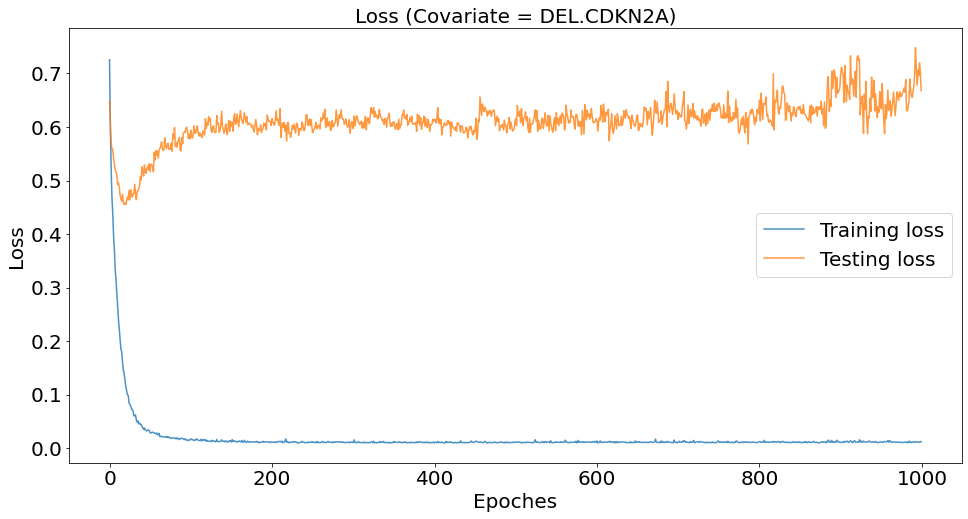

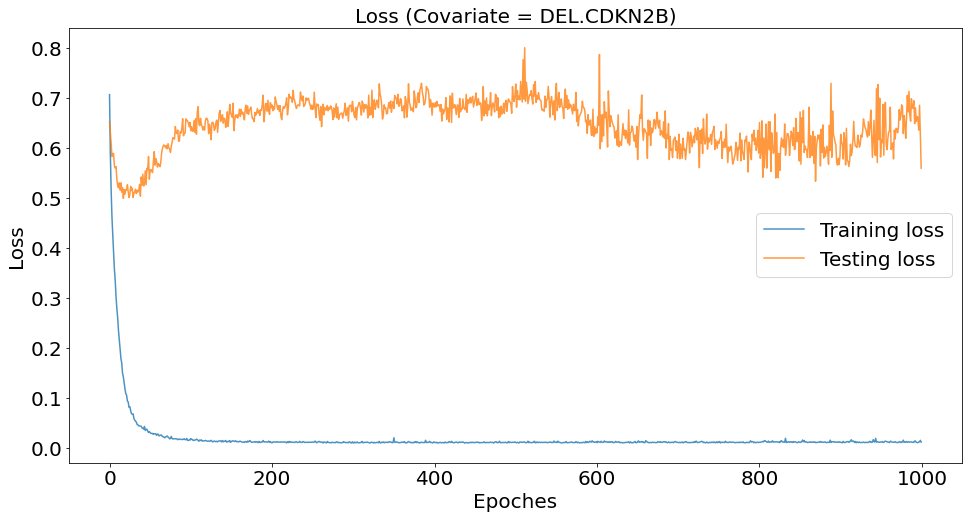

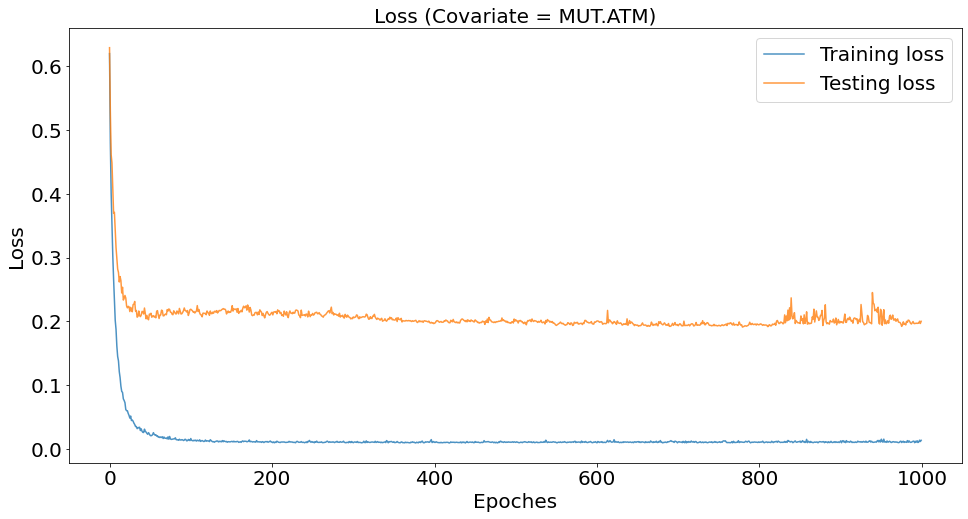

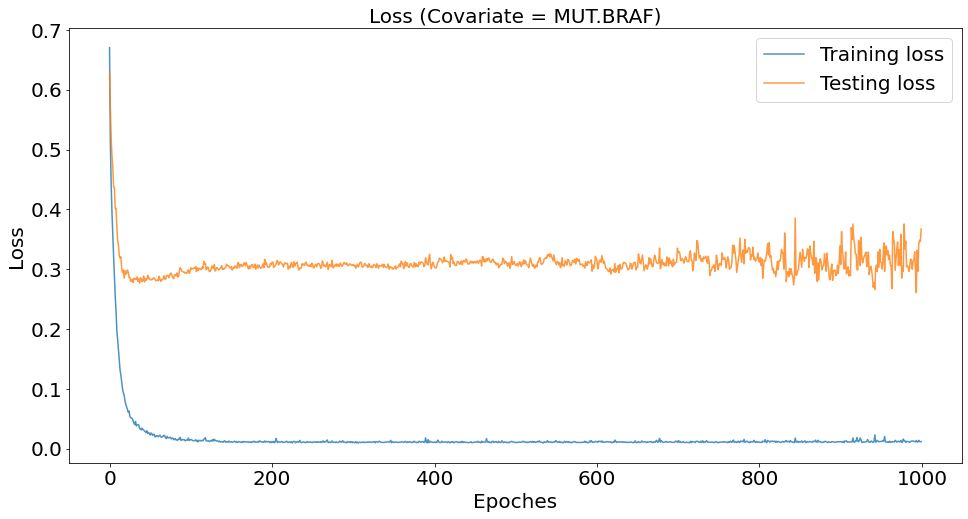

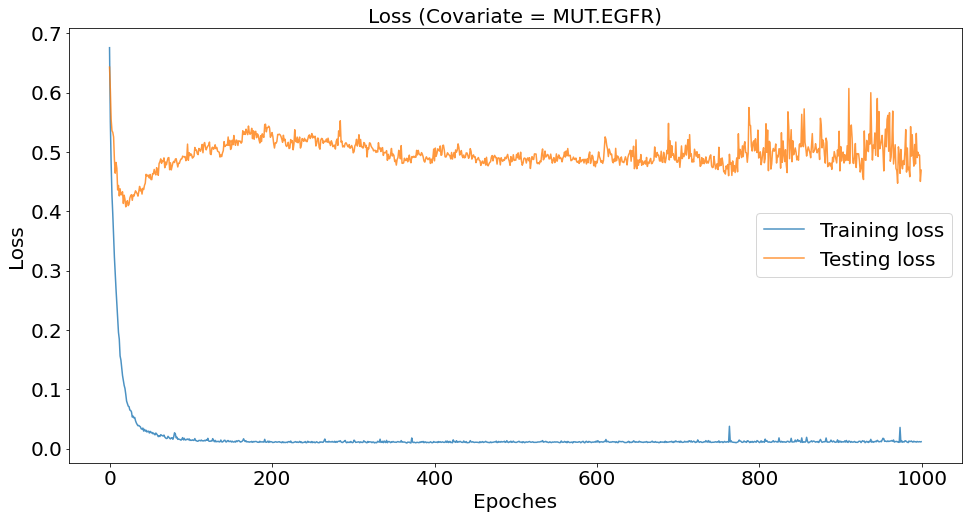

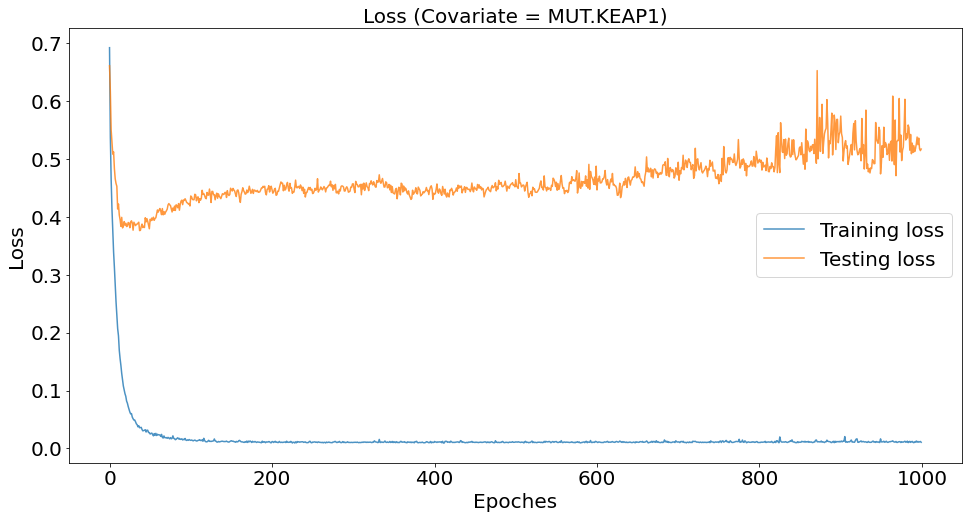

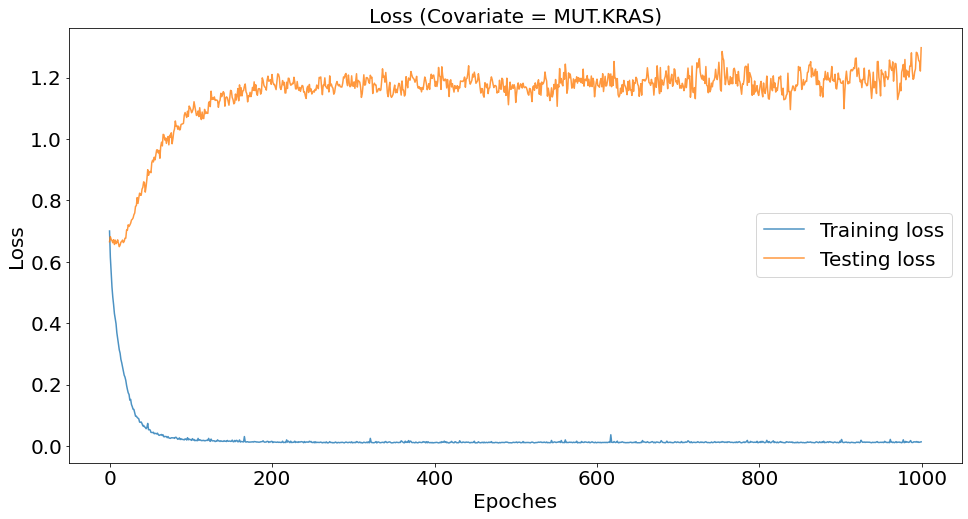

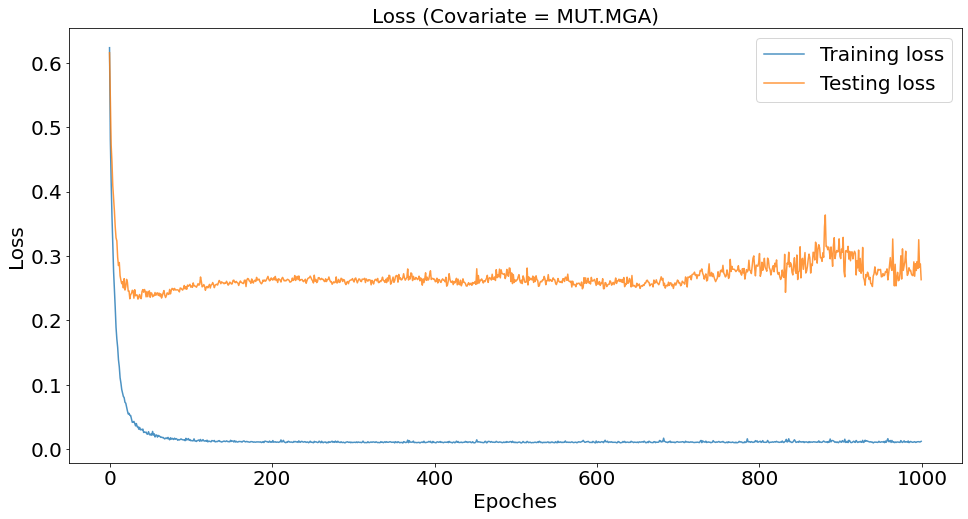

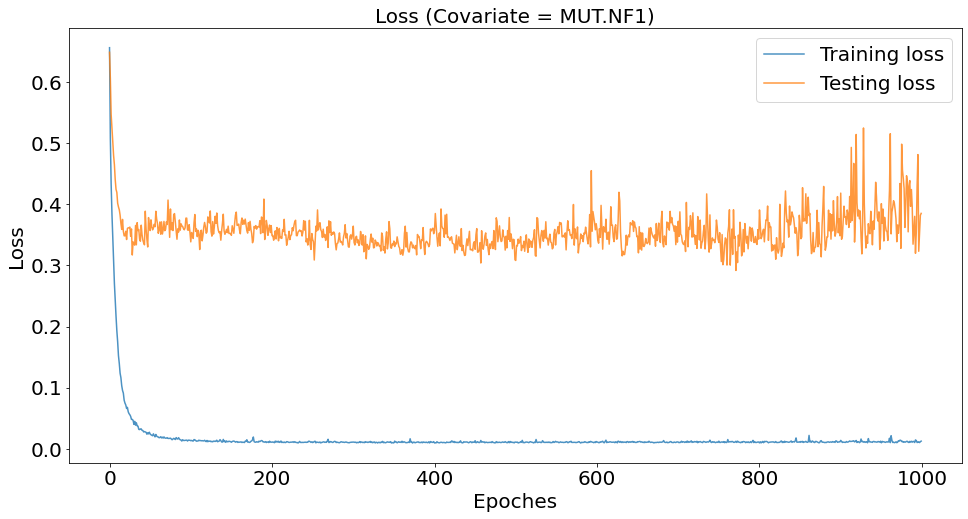

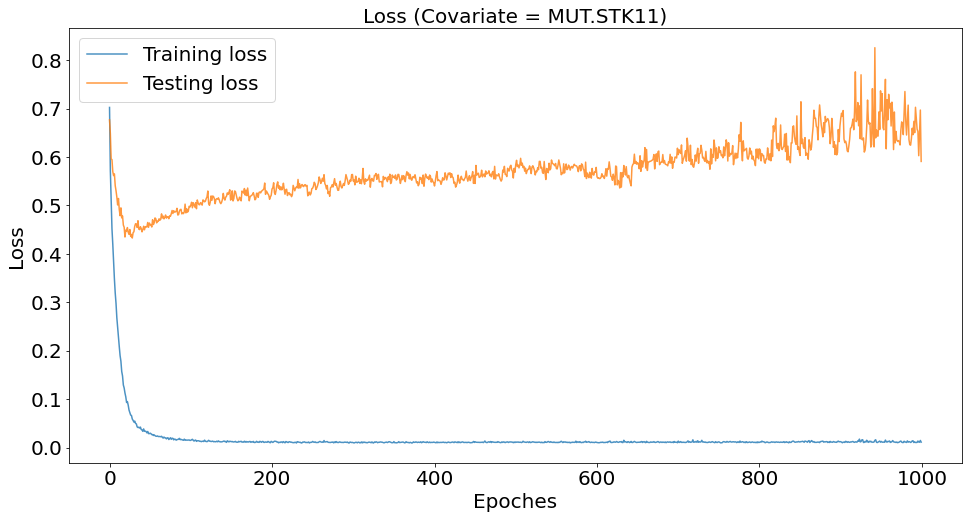

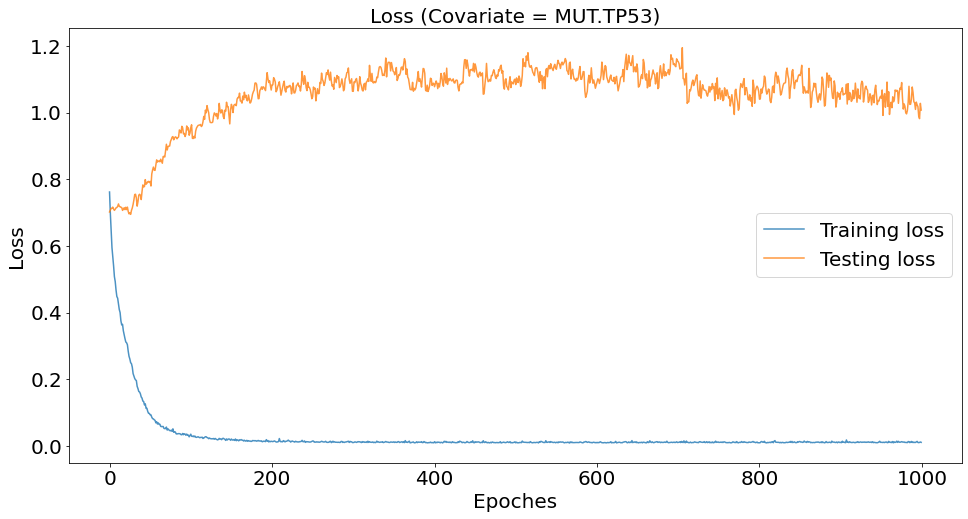

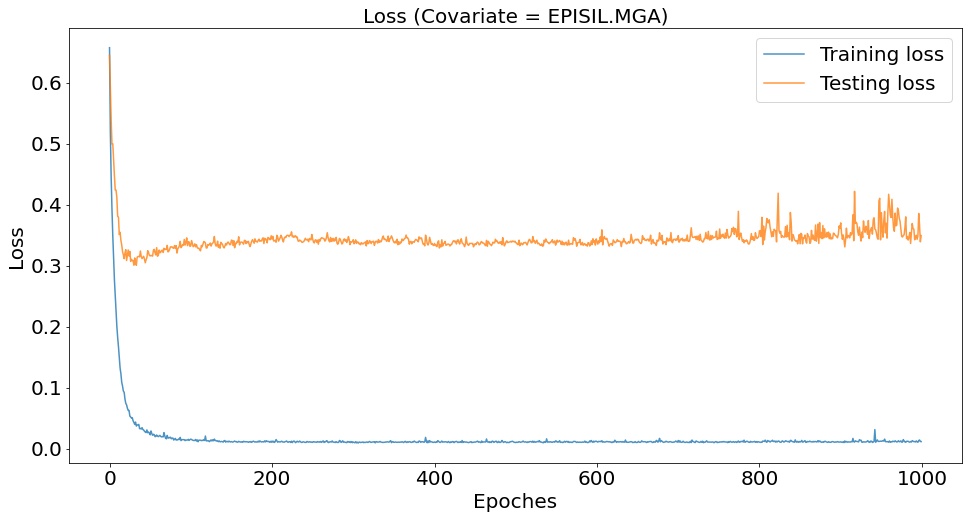

CPU times: user 33min 40s, sys: 1min 7s, total: 34min 47s
Wall time: 34min 1s


In [31]:
%%time
LUAD_prediction_result_dict = train_mlp_all_cols('LUAD', device=device, dropout_rate=0., weight_decay=0.01)

In [32]:
LUAD_prediction_result_dict['auc']

{'AMP.CDK4': 0.4456140350877193,
 'AMP.MYC': 0.47177419354838707,
 'AMP.RICTOR': 0.606280193236715,
 'AMP.EGFR': 0.4375,
 'AMP.KRAS': 0.38596491228070173,
 'AMP.MDM2': 0.6479166666666667,
 'DEL.CDKN2A': 0.6519607843137255,
 'DEL.CDKN2B': 0.6220588235294118,
 'MUT.ATM': 0.3530927835051546,
 'MUT.BRAF': 0.3723404255319149,
 'MUT.EGFR': 0.4232323232323232,
 'MUT.KEAP1': 0.5197802197802197,
 'MUT.KRAS': 0.43456221198156675,
 'MUT.MGA': 0.32708333333333334,
 'MUT.NF1': 0.375438596491228,
 'MUT.STK11': 0.5323426573426573,
 'MUT.TP53': 0.6274509803921569,
 'EPISIL.MGA': 0.22644376899696045}

In [33]:
len(list(LUAD_prediction_result_dict['auc'].keys()))

18

In [34]:
np.sort(list(LUAD_prediction_result_dict['auc'].values()))[::-1]

array([0.65196078, 0.64791667, 0.62745098, 0.62205882, 0.60628019,
       0.53234266, 0.51978022, 0.47177419, 0.44561404, 0.4375    ,
       0.43456221, 0.42323232, 0.38596491, 0.3754386 , 0.37234043,
       0.35309278, 0.32708333, 0.22644377])

### LUSC

(464, 27)


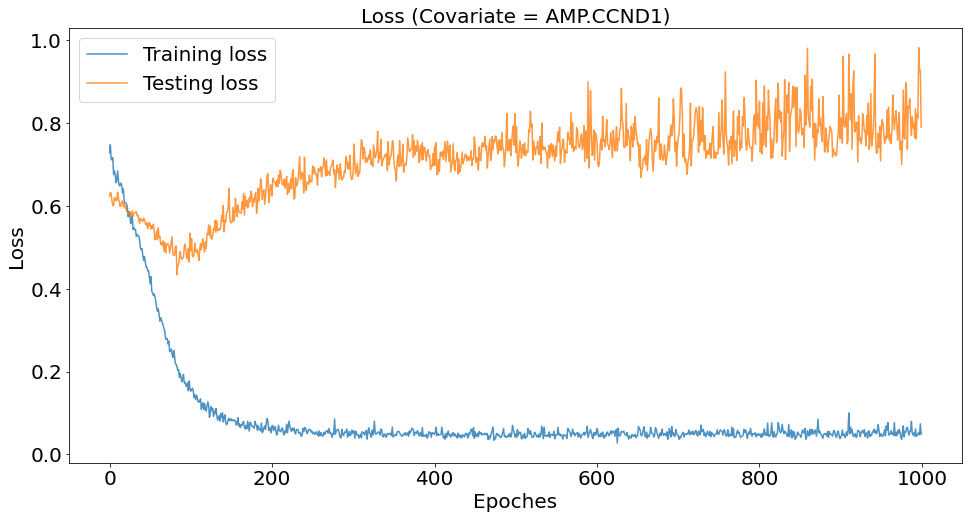

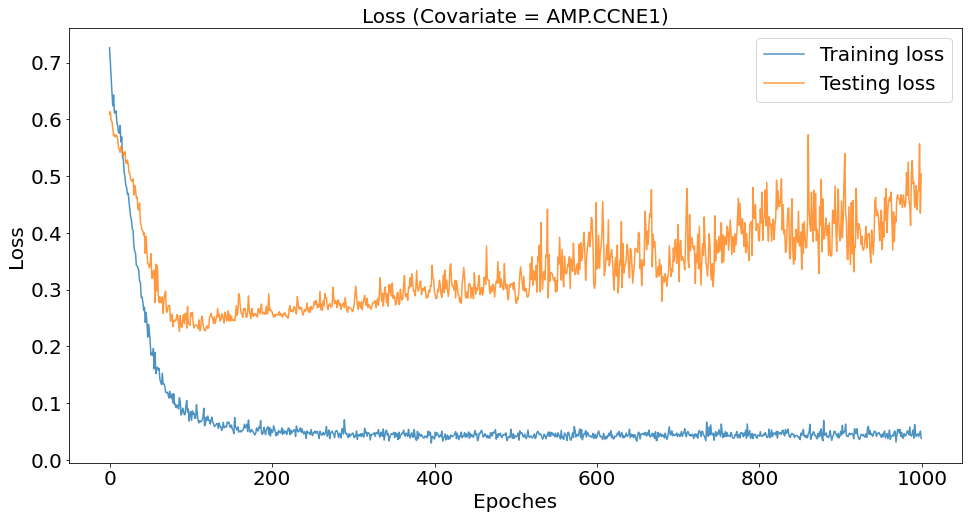

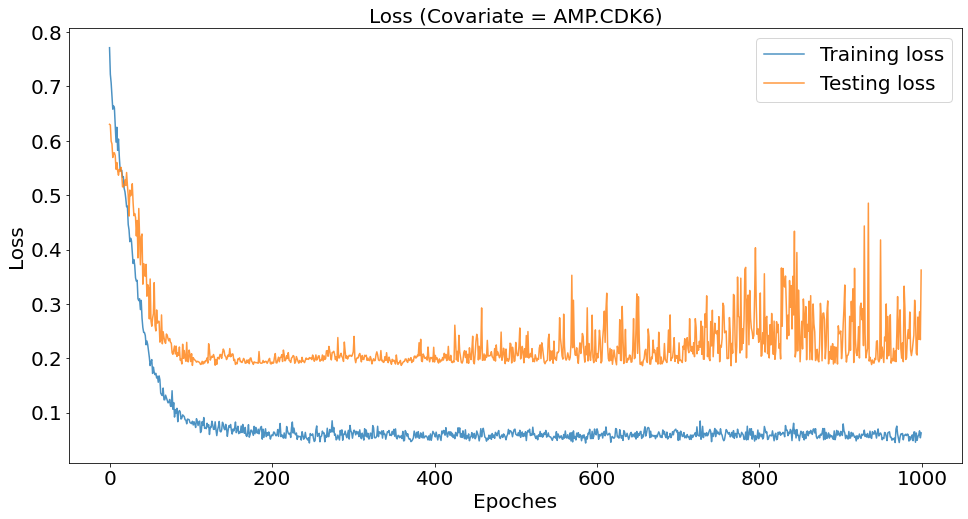

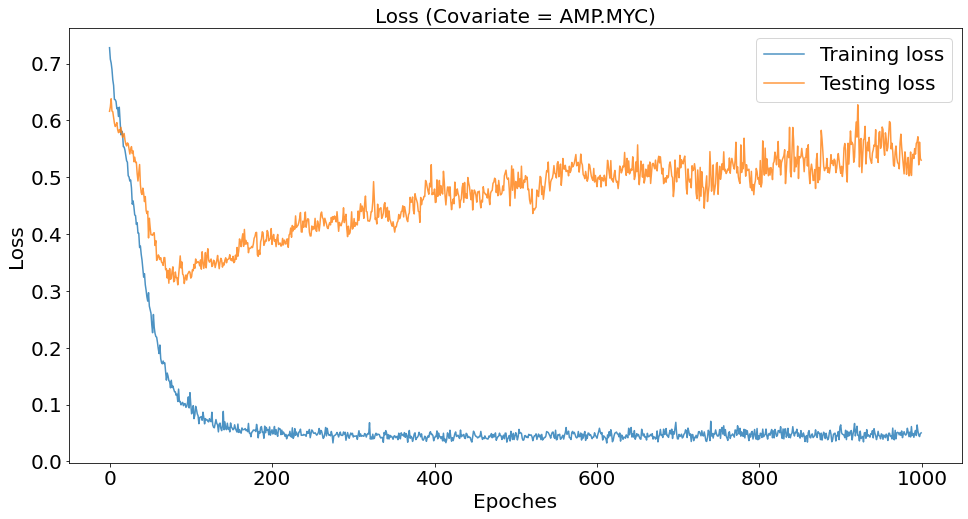

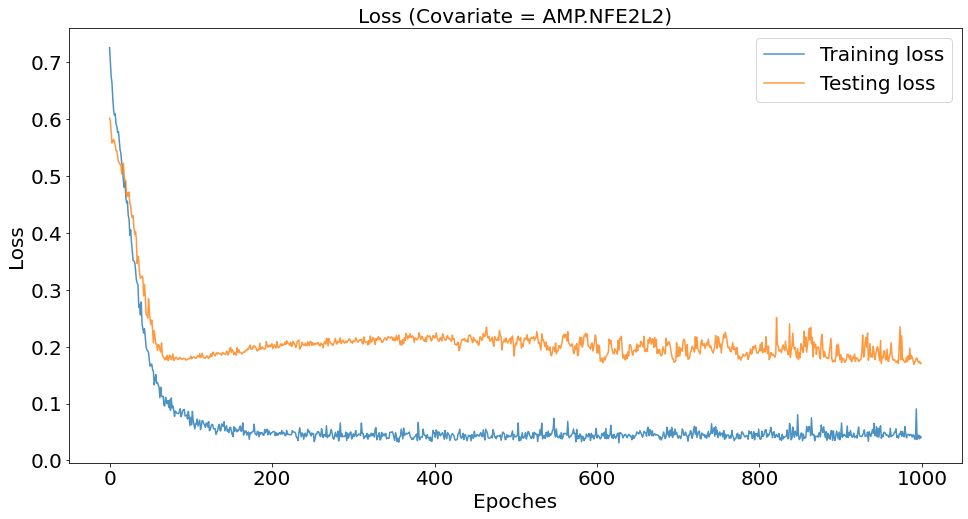

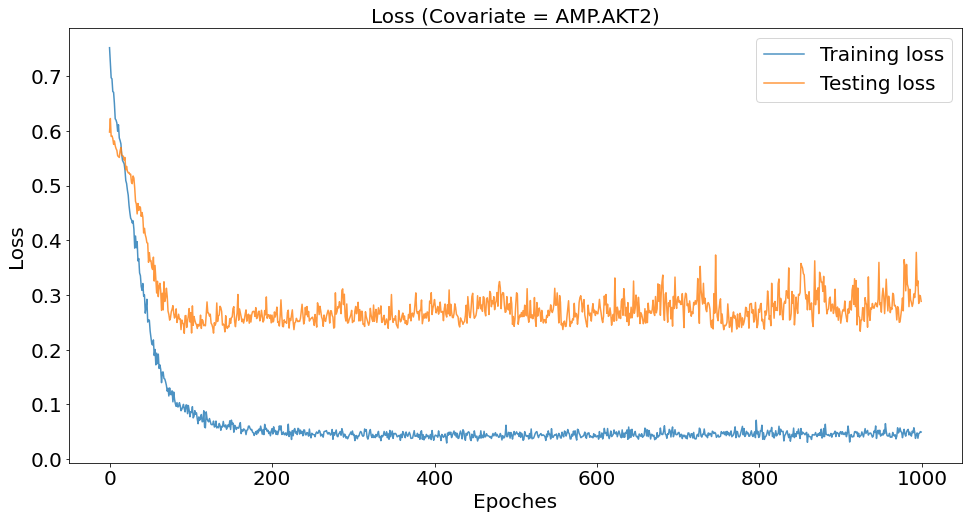

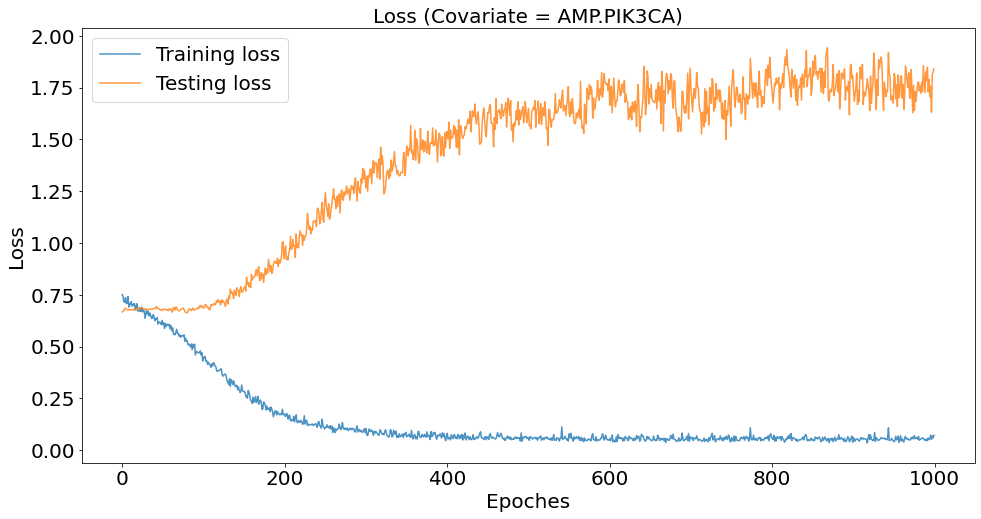

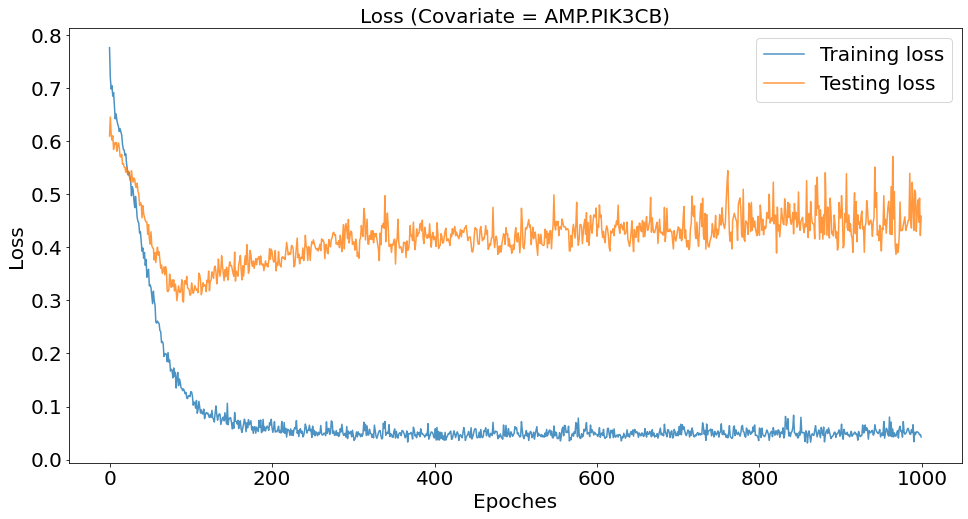

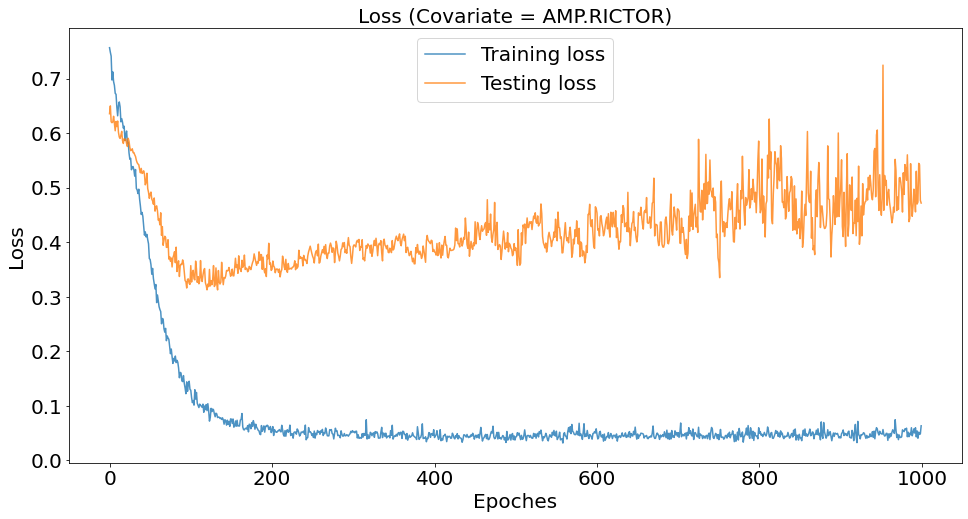

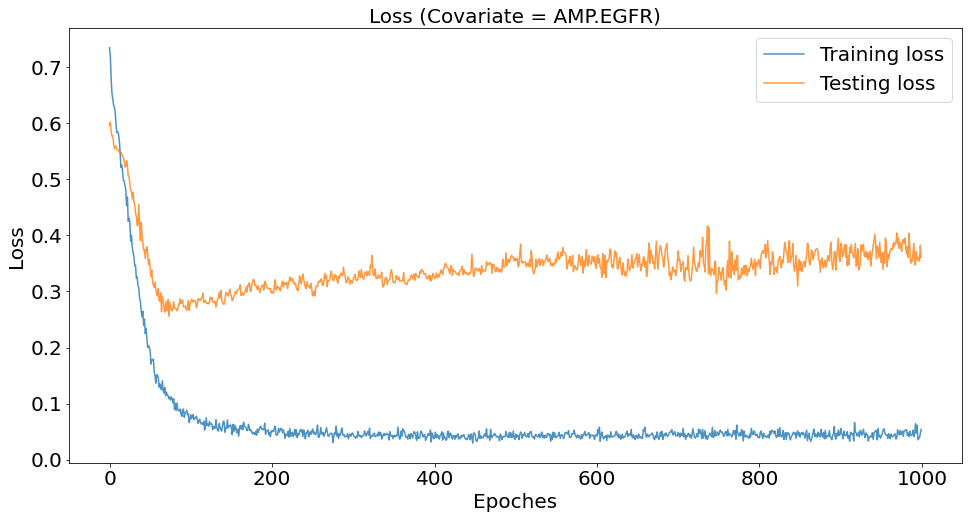

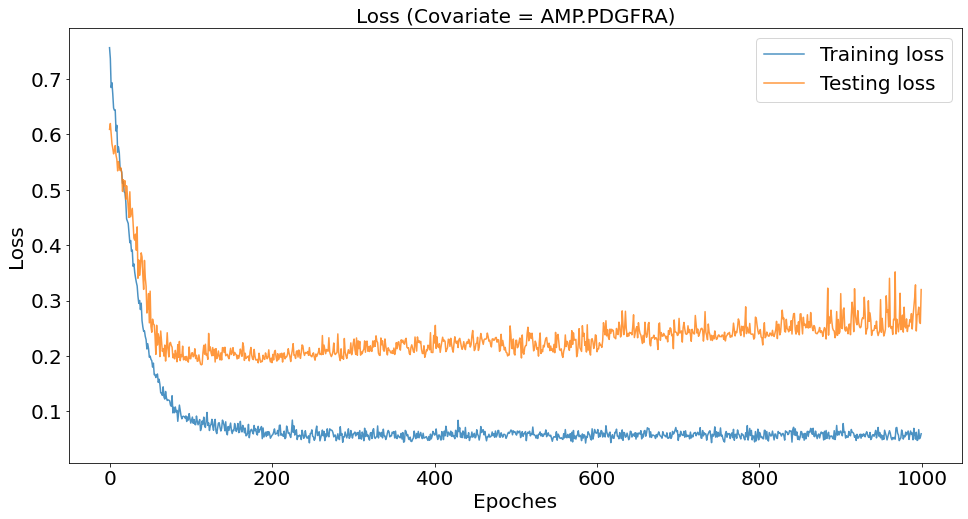

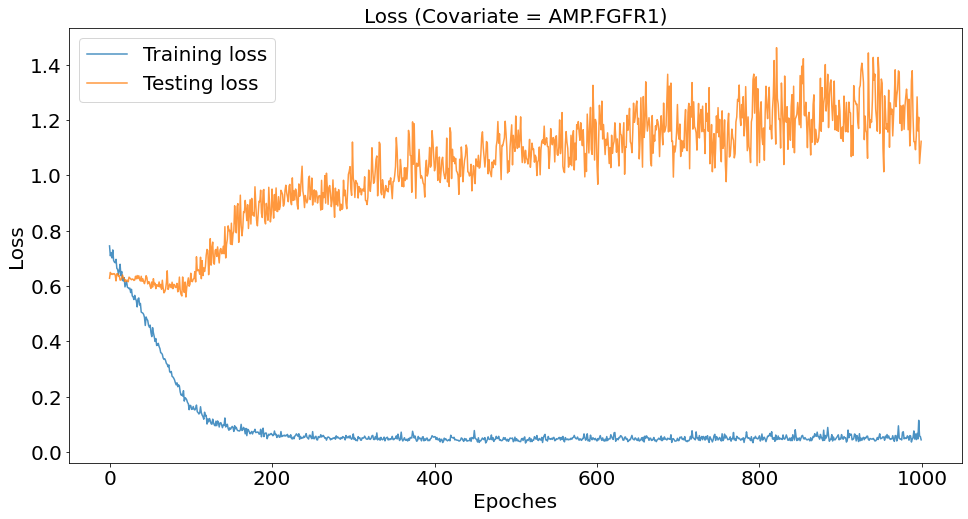

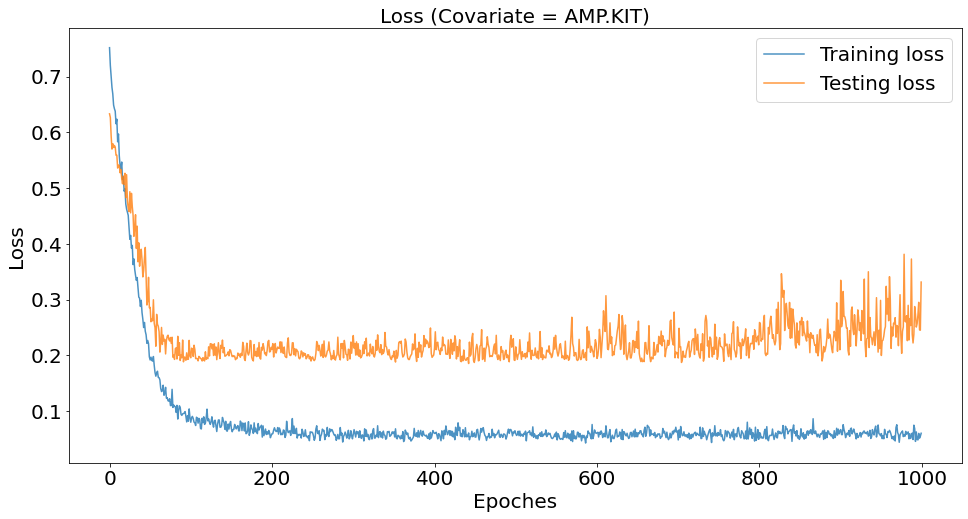

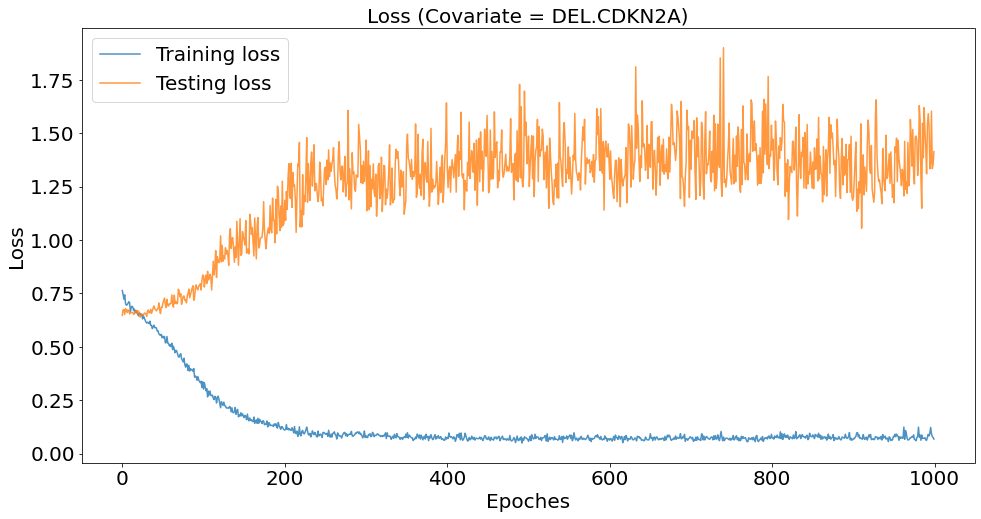

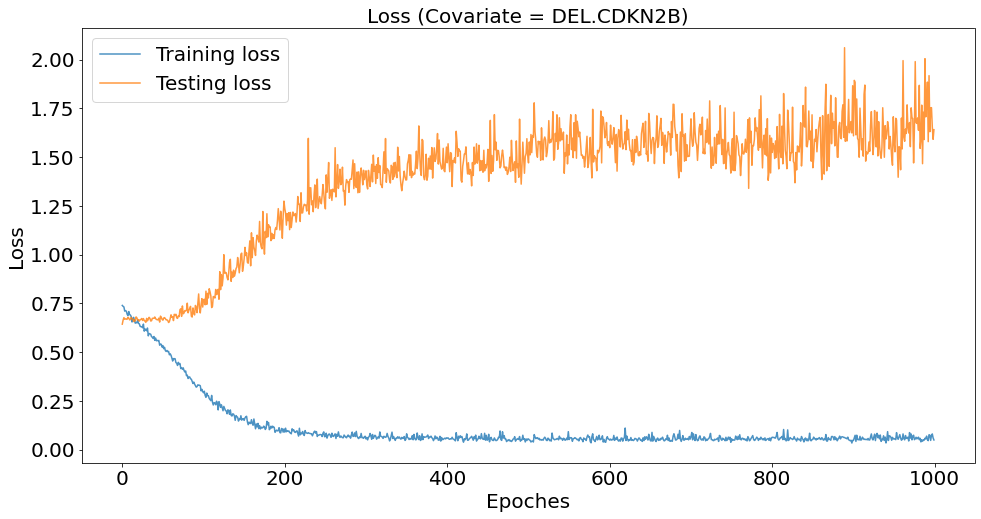

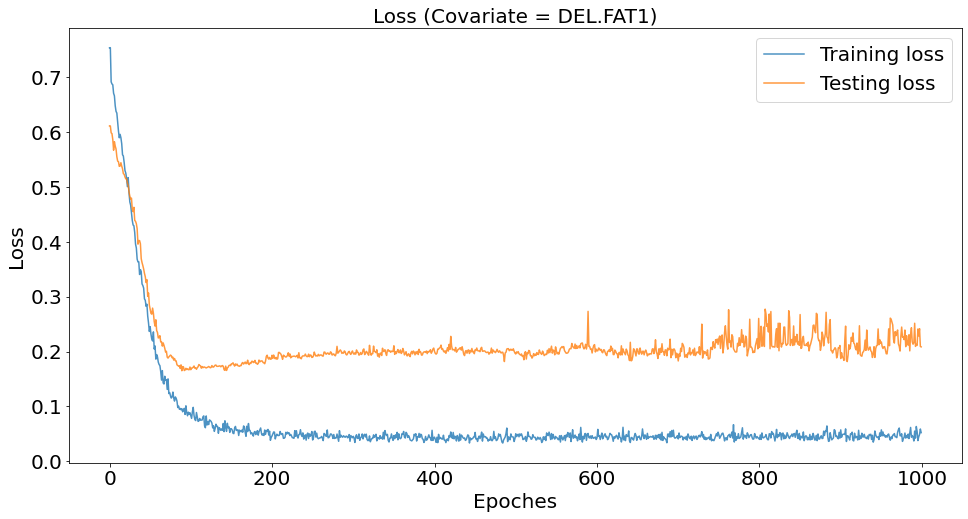

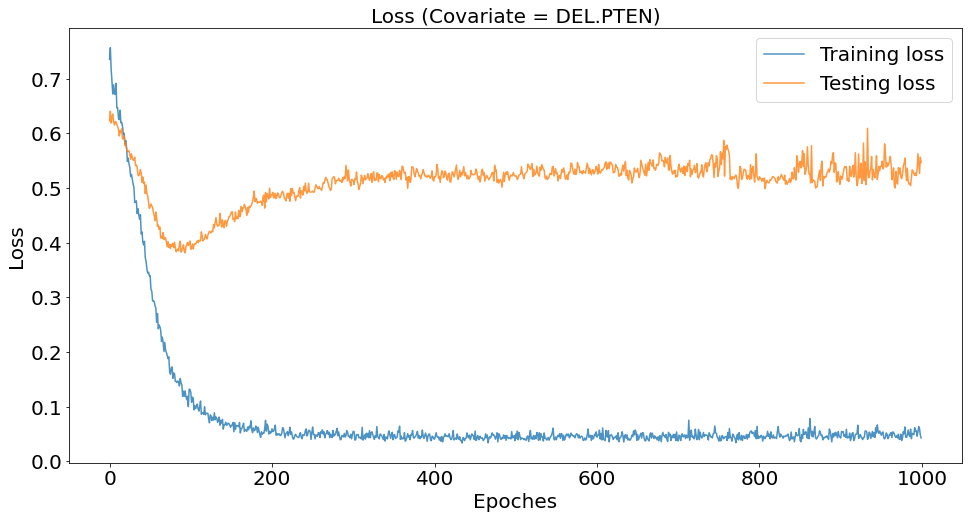

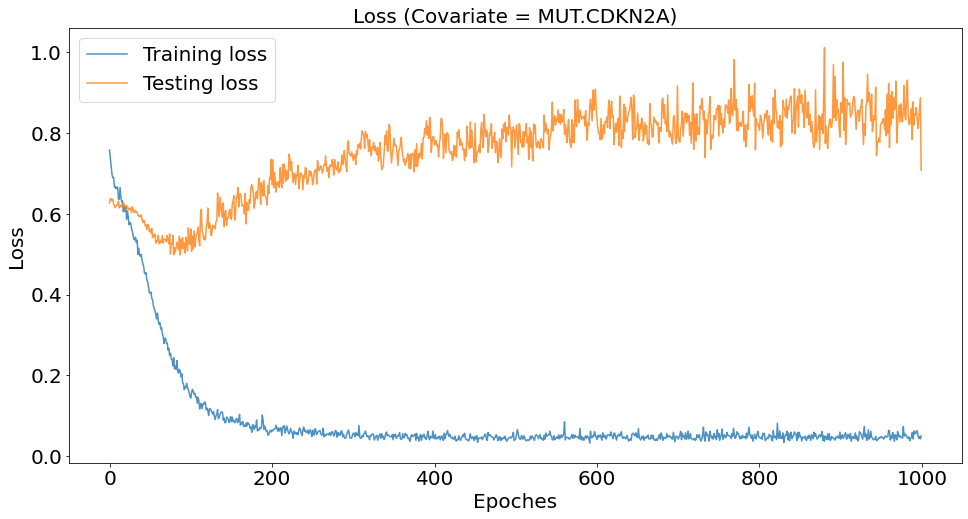

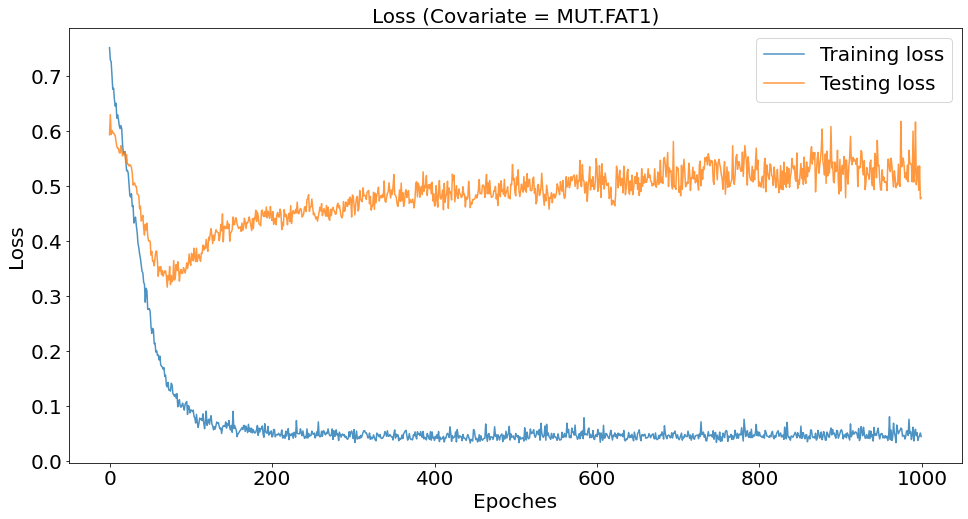

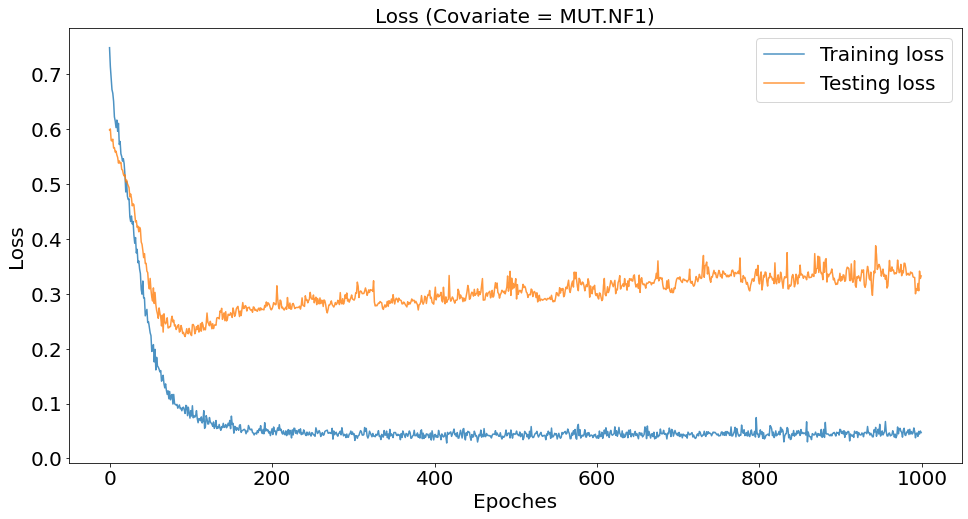

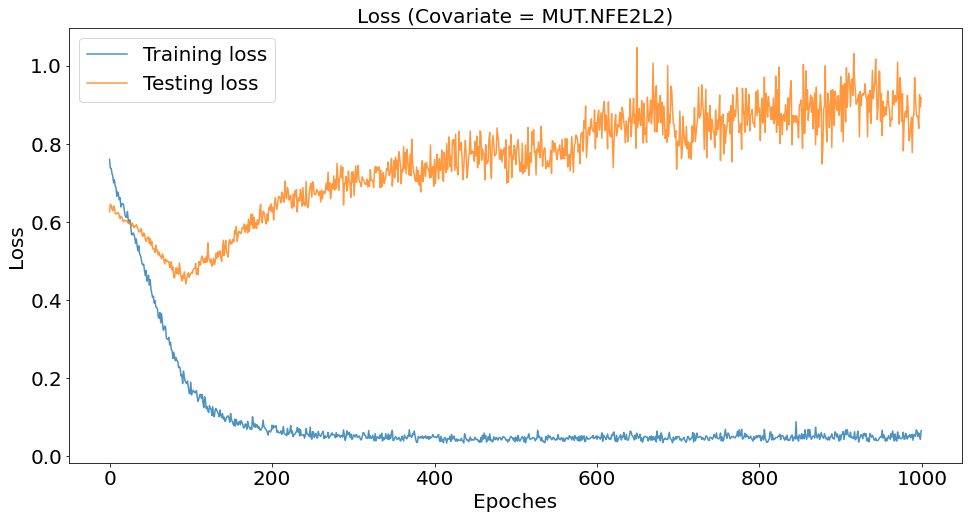

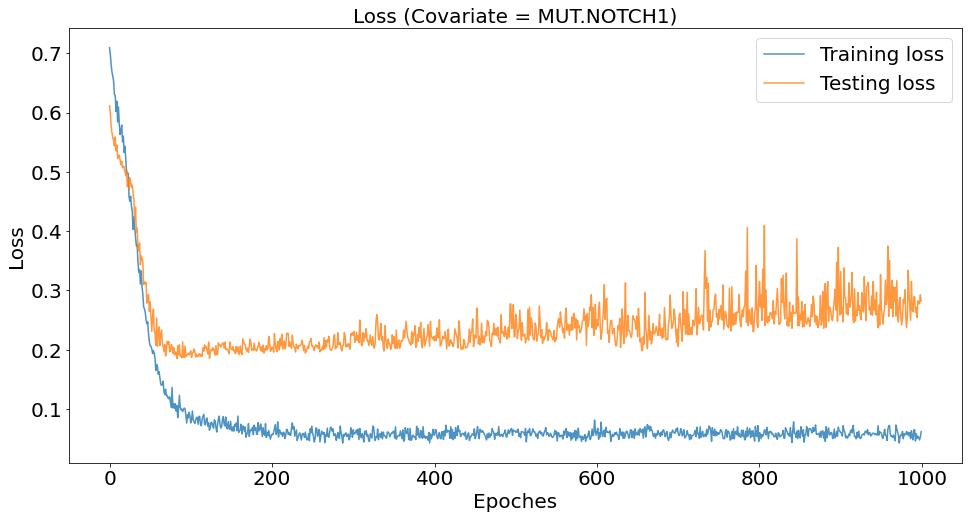

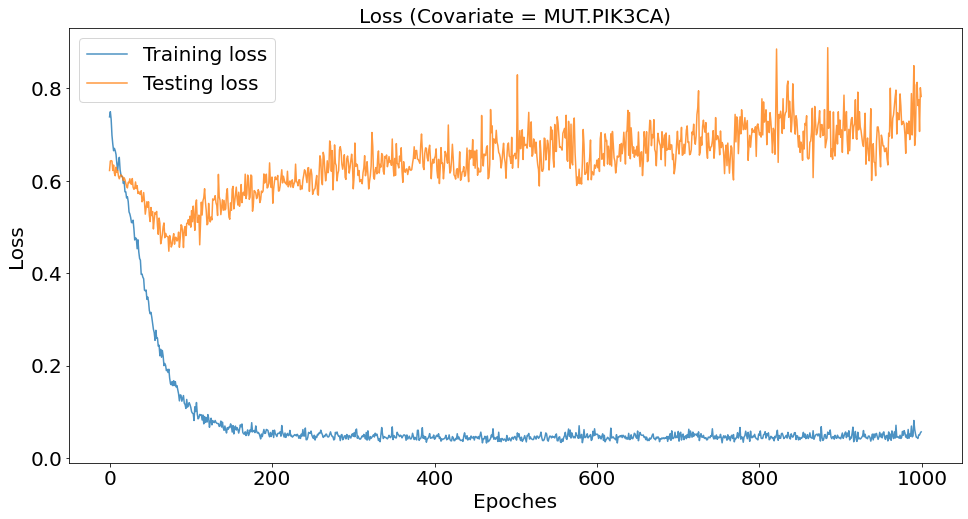

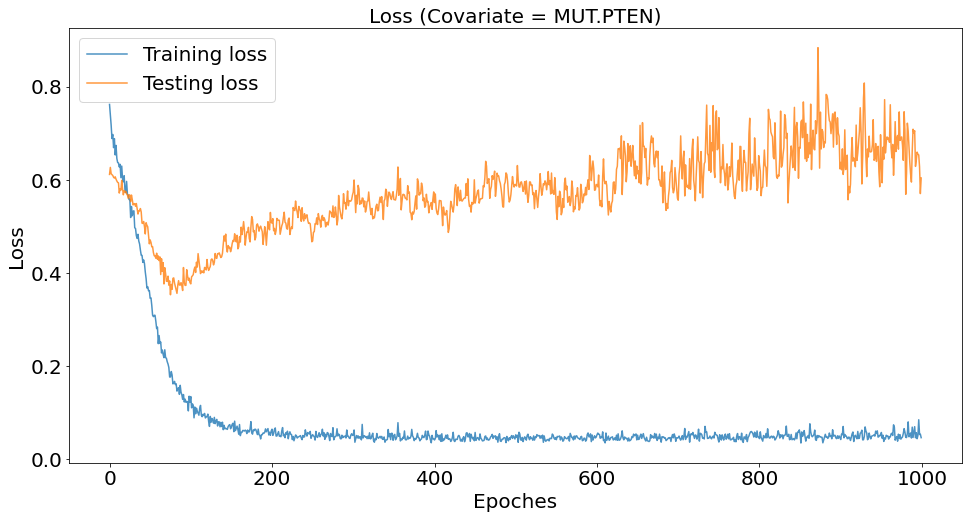

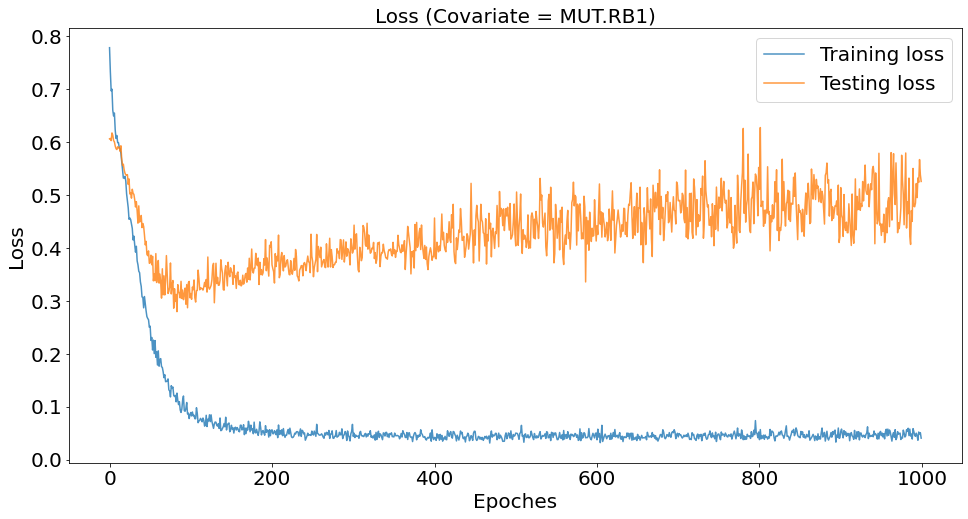

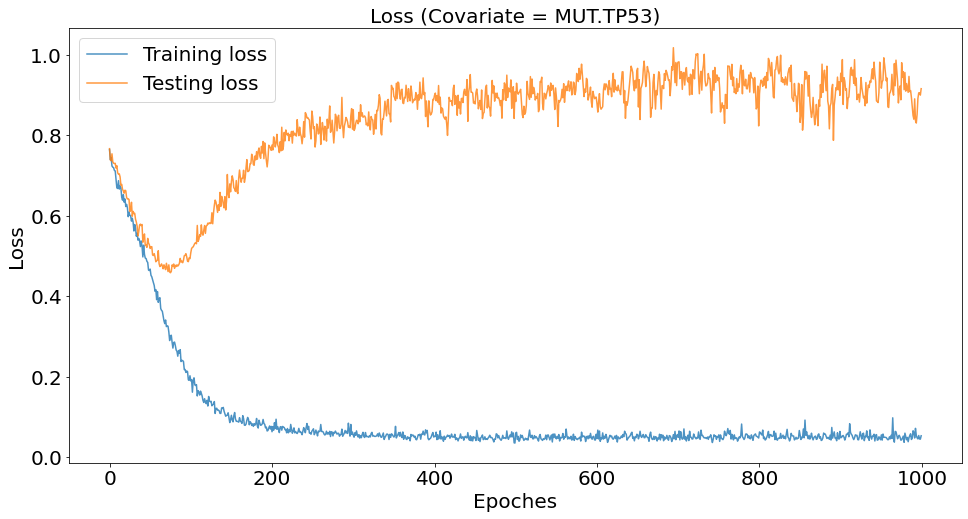

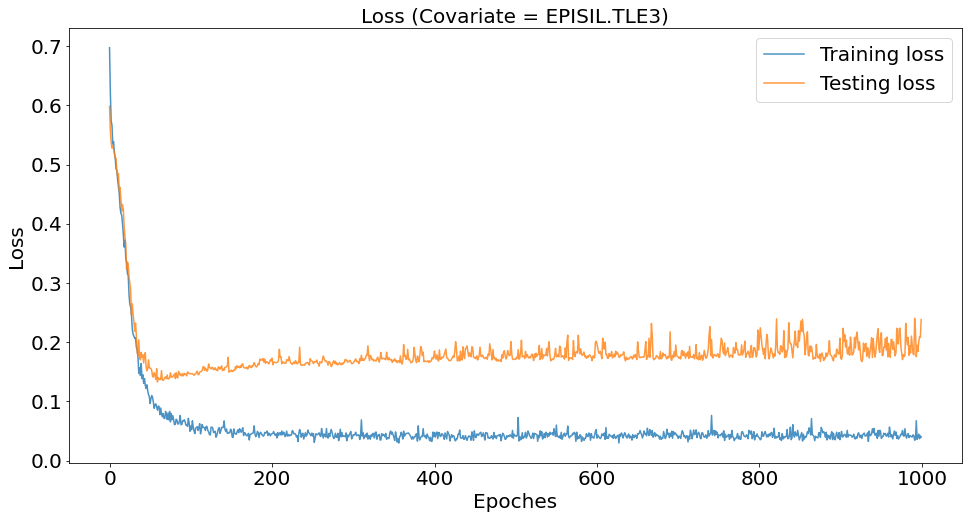

CPU times: user 49min 10s, sys: 1min 49s, total: 51min
Wall time: 49min 43s


In [35]:
%%time
LUSC_prediction_result_dict = train_mlp_all_cols('LUSC', device=device, dropout_rate=0.4, weight_decay=0.01)

In [36]:
LUSC_prediction_result_dict['auc']

{'AMP.CCND1': 0.4660493827160494,
 'AMP.CCNE1': 0.48409090909090907,
 'AMP.CDK6': 0.28230337078651685,
 'AMP.MYC': 0.6777408637873754,
 'AMP.NFE2L2': 0.7078651685393258,
 'AMP.AKT2': 0.6840909090909091,
 'AMP.PIK3CA': 0.4975369458128079,
 'AMP.PIK3CB': 0.4455882352941176,
 'AMP.RICTOR': 0.6987951807228916,
 'AMP.EGFR': 0.5670498084291188,
 'AMP.PDGFRA': 0.4620786516853932,
 'AMP.FGFR1': 0.49512987012987014,
 'AMP.KIT': 0.4269662921348315,
 'DEL.CDKN2A': 0.429951690821256,
 'DEL.CDKN2B': 0.3158212560386473,
 'DEL.FAT1': 0.8340909090909091,
 'DEL.PTEN': 0.5626506024096385,
 'MUT.CDKN2A': 0.5057692307692307,
 'MUT.FAT1': 0.651470588235294,
 'MUT.NF1': 0.4545454545454546,
 'MUT.NFE2L2': 0.5475961538461539,
 'MUT.NOTCH1': 0.44662921348314605,
 'MUT.PIK3CA': 0.46024096385542174,
 'MUT.PTEN': 0.6325301204819277,
 'MUT.RB1': 0.5842911877394636,
 'MUT.TP53': 0.5837606837606838,
 'EPISIL.TLE3': 0.8426966292134831}

In [37]:
len(list(LUSC_prediction_result_dict['auc'].keys()))

27

In [38]:
np.sort(list(LUSC_prediction_result_dict['auc'].values()))[::-1]

array([0.84269663, 0.83409091, 0.70786517, 0.69879518, 0.68409091,
       0.67774086, 0.65147059, 0.63253012, 0.58429119, 0.58376068,
       0.56704981, 0.5626506 , 0.54759615, 0.50576923, 0.49753695,
       0.49512987, 0.48409091, 0.46604938, 0.46207865, 0.46024096,
       0.45454545, 0.44662921, 0.44558824, 0.42995169, 0.42696629,
       0.31582126, 0.28230337])